# End to End forcasting pipeline from scratch

Predictive Modeling:

Accurate electricity demand forecasting is essential for anticipating future energy requirements, estimating carbon emissions, and supporting operational planning. To maintain high accuracy in dynamic energy markets, the platform employs a robust online and incremental learning framework alongside its core multi-model architecture, allowing models to continuously adapt to evolving demand patterns and concept drift without requiring full retraining from scratch.

Adaptive AI Models: The platform uses a blend of specialized neural networks (LSTM and TFT) alongside Google's advanced time-series AI (TimesFM) using transfer learning. These models learn long-term patterns while continuously tweaking their internal weights using incoming streaming data to handle sudden load shifts and concept drift.
Smart Uncertainty Ranges (Probabilistic Forecasts): Rather than guessing a single fixed number, the models provide a range of outcomes—specifically P10, P50, and P90 estimates. This means it calculates conservative, expected, and peak demand scenarios so decision-makers can plan for best- and worst-case situations safely.
Auto-Correcting Accuracy: The platform uses automated safety checks (conformal calibration) to continuously monitor its own error rates. If forecasts start drifting off target, the system self-corrects its uncertainty ranges and seamlessly falls back to a reliable backup baseline model if any anomaly occurs.
Model Optimization & Efficiency: To ensure low-latency performance and a lightweight resource footprint, the platform applies **structured pruning** to remove redundant internal layers and connections from deep architectures. It then uses **fine-tuning** workflows to recover any predictive accuracy lost during the pruning phase prior to live production deployment.


Carbon Insights:
Forecasting electricity demand alone does not indicate the environmental impact of meeting that demand. The platform therefore combines demand forecasts with carbon intensity and renewable energy data obtained from external providers. This enables users to estimate future carbon emissions alongside future electricity demand, supporting sustainability reporting and operational decision-making.
Where renewable energy metrics are unavailable, the platform derives the renewable proportion from the observed electricity generation mix, ensuring carbon insights remain available even when external data is incomplete

Model Lifecycle Management:
Machine learning models continuously evolve as new data becomes available and forecasting performance improves. The platform uses MLflow to manage the complete model lifecycle, including experiment tracking, model versioning, artifact storage, validation, and deployment.
Although these tasks could be managed manually, MLflow provides a standardized and reproducible workflow. It records training parameters, evaluation metrics, datasets, and model artifacts for every experiment, making it easy to compare model versions, reproduce previous results, and safely promote validated models into production. This improves collaboration, simplifies model governance, and ensures consistent production inference.


---

## Tutorial roadmap

This notebook walks through the real code behind every capability described above, one
inspectable step per cell, using the actual `app.service.ml`/`app.models`/
`app.service.mlops` modules `services/forecast-api` trains and serves with -- nothing
here is a simplified standalone reimplementation.

**V2 note**: identical to `forcast_pipeline.ipynb` through Step 13 -- Step 14 is
rewritten to export **ONNX** instead of the `.pt` `state_dict` bundle (see that step's
own markdown for why, and its current real-vs-aspirational status).

| # | Section | What it demonstrates |
|---|---|---|
| 0 | Setup | Import the real pipeline modules |
| 1 | Configuration | The knobs you'll actually touch |
| 2 | Load data from DuckDB | The data source this whole notebook runs on |
| 3 | Look before you train | Missingness + a sanity plot |
| 4 | Feature engineering | Lags, rolling stats, calendar features |
| 5-6 | Train `DemandLSTM` | Chronological split, per-region scaling, quantile heads, **conformal calibration**, **bias correction** |
| 7 | Inspect the trained model | Loss curves, real calibrated coverage |
| 8 | Baseline fallback | The trained model vs. the "always available" seasonal-naive floor |
| 9 | Visualize a forecast | P10-P90 band vs. actual, via the real serving-path `LSTMForecaster` |
| 10 | Structured pruning | Real size/latency reduction, measured |
| 11 | Carbon insights | Real NGER emission factors + real generation mix -> emissions & intensity |
| 12 | Beyond LSTM: TFT & TimesFM | Zero-shot TimesFM alongside the trained LSTM, and where TFT/continuous adaptation fit |
| 13 | MLflow lifecycle | Registration, and how promotion is gated |
| 14 | Export to ONNX | Framework-agnostic export, self-verified against the original PyTorch model, packaged for `POST /v1/model/versions/import-onnx` -- not yet built, see that step's own note |

**Prerequisites:** run this notebook with `services/forecast-api/.venv`'s Python as the
Jupyter kernel -- it already has `duckdb`, `torch`, `onnx`/`onnxruntime`, `mlflow`, and
everything else this pipeline needs. No GPU required.


## Step 0 -- Setup

In [56]:
# Colab only needs this one install -- torch/pandas/numpy/scikit-learn/
# matplotlib all ship pre-installed. duckdb does not.
!pip install -q duckdb


In [57]:
import duckdb
import pandas as pd

# Replace the path with the location of your .duckdb file in your Drive
db_path = '../../ingestion/data/staging/landed.duckdb'

# Establish the connection (ensure no conflicting connections are open in other cells)
conn = duckdb.connect(str(db_path), read_only=True)

# Fetch all tables using standard information schema or duckdb_tables
tables = conn.execute("SELECT table_name FROM duckdb_tables();").fetchall()

data = []
for (table_name,) in tables:
    count = conn.execute(f'SELECT count(*) FROM "{table_name}"').fetchone()[0]
    data.append({"table_name": table_name, "row_count": count})

df_summary = (
    pd.DataFrame(data)
    .sort_values(by="row_count", ascending=False)
    .reset_index(drop=True)
)

display(df_summary)

# # Optional: explicitly close connection when done to prevent caching locks
# conn.close()

,table_name,row_count
0,aemo_nem_dispatch,1358005
1,openelectricity_mix,1270957
2,bom_observations,237570
3,aemo_wem_dispatch,211104
4,aemo_holidays,390


In [58]:
# Build master table
from pathlib import Path
import pandas as pd
import duckdb



_REGIONS = ["NSW1", "QLD1", "SA1", "TAS1", "VIC1", "WEM"]
_BOM_STATION_MAP = {
    '009225': 'WEM',
    '023034': 'SA1',
    '040913': 'QLD1',
    '066037': 'NSW1',
    '086282': 'VIC1',
    '094029': 'TAS1',
}

def build_master_panel(db_path: str | Path) -> pd.DataFrame:
    """Builds the local, wide 30-minute-grain master training table using Pandas."""
    conn = duckdb.connect(str(db_path), read_only=True)

    # 1. Load Staging Tables from DuckDB into Pandas
    nem_df = conn.execute("SELECT * FROM aemo_nem_dispatch").fetchdf()
    wem_df = conn.execute("SELECT * FROM aemo_wem_dispatch").fetchdf()
    oe_df = conn.execute("SELECT * FROM openelectricity_mix").fetchdf()
    bom_df = conn.execute("SELECT * FROM bom_observations").fetchdf()
    holidays_df = conn.execute("SELECT DISTINCT date, region, holiday_name, is_workday FROM aemo_holidays").fetchdf()

    conn.close()

    # Ensure timestamp dtypes
    for df in [nem_df, wem_df, oe_df, bom_df]:
        if 'ts' in df.columns:
            df['ts'] = pd.to_datetime(df['ts'])

    # 2. Process AEMO Demand & Dispatch (Union NEM + WEM with column alignment)
    nem_df['diesel_mw'] = None
    nem_df['biomass_mw'] = None
    nem_df['total_generation_mw'] = None

    wem_df['hydro_mw'] = None
    wem_df['net_import_mw'] = None

    aemo_combined = pd.concat([nem_df, wem_df], ignore_index=True)
    aemo_combined['bucket_ts'] = aemo_combined['ts'].dt.floor('30min')

    aemo_agg_cols = {
        'demand_mw': 'aemo_demand_mw',
        'price_mwh': 'aemo_price_mwh',
        'coal_mw': 'aemo_coal_mw',
        'gas_mw': 'aemo_gas_mw',
        'hydro_mw': 'aemo_hydro_mw',
        'wind_mw': 'aemo_wind_mw',
        'solar_utility_mw': 'aemo_solar_utility_mw',
        'solar_rooftop_mw': 'aemo_solar_rooftop_mw',
        'battery_mw': 'aemo_battery_mw',
        'net_import_mw': 'aemo_net_import_mw',
        'diesel_mw': 'aemo_diesel_mw',
        'biomass_mw': 'aemo_biomass_mw',
        'total_generation_mw': 'aemo_total_generation_mw'
    }

    aemo_demand = (
        aemo_combined.groupby(['bucket_ts', 'region'])[list(aemo_agg_cols.keys())]
        .mean()
        .rename(columns=aemo_agg_cols)
        .reset_index()
    )

    # 3. Process OpenElectricity Mix
    oe_df['bucket_ts'] = oe_df['ts'].dt.floor('30min')
    oe_agg_cols = {
        'demand_mw': 'oe_demand_mw',
        'price_mwh': 'oe_price_mwh',
        'intensity_kg_per_mwh': 'oe_intensity_kg_per_mwh',
        'battery_discharge_mw': 'oe_battery_discharge_mw',
        'battery_charge_mw': 'oe_battery_charge_mw',
        'biomass_mw': 'oe_biomass_mw',
        'coal_mw': 'oe_coal_mw',
        'distillate_mw': 'oe_distillate_mw',
        'gas_mw': 'oe_gas_mw',
        'hydro_mw': 'oe_hydro_mw',
        'pumped_hydro_mw': 'oe_pumped_hydro_mw',
        'solar_rooftop_mw': 'oe_solar_rooftop_mw',
        'solar_utility_mw': 'oe_solar_utility_mw',
        'wind_mw': 'oe_wind_mw',
        'total_generation_mw': 'oe_total_generation_mw',
        'total_renewable_mw': 'oe_total_renewable_mw'
    }

    oe_mix = (
        oe_df.groupby(['bucket_ts', 'region'])[list(oe_agg_cols.keys())]
        .mean()
        .rename(columns=oe_agg_cols)
        .reset_index()
    )

    # 4. Process Weather Observations (Map stations to regions and bucket timestamps)
    bom_df['region'] = bom_df['station_id'].map(_BOM_STATION_MAP)
    bom_df = bom_df.dropna(subset=['region'])
    bom_df['bucket_ts'] = bom_df['ts'].dt.floor('30min')

    weather_agg_cols = {
        'temp_c': 'temp_c',
        'apparent_temp_c': 'apparent_temp_c',
        'dew_point_c': 'dew_point_c',
        'humidity_pct': 'humidity_pct',
        'wind_speed_kmh': 'wind_speed_kmh',
        'wind_direction_deg': 'wind_direction_deg',
        'wind_gust_kmh': 'wind_gust_kmh',
        'pressure_hpa': 'pressure_hpa',
        'rain_since_9am_mm': 'rain_since_9am_mm',
        'cloud_oktas': 'cloud_oktas'
    }

    weather = (
        bom_df.groupby(['bucket_ts', 'region'])[list(weather_agg_cols.keys())]
        .mean()
        .rename(columns=weather_agg_cols)
        .reset_index()
        .sort_values('bucket_ts')
    )

    # 5. Construct Full Rectangular Grid (bucket_ts × region)
    all_buckets = pd.concat([aemo_demand['bucket_ts'], oe_mix['bucket_ts']]).unique()
    grid_index = pd.MultiIndex.from_product([all_buckets, _REGIONS], names=['bucket_ts', 'region'])
    grid = pd.DataFrame(index=grid_index).reset_index()

    # 6. Merge Datasets onto the Grid
    master = grid.merge(aemo_demand, on=['bucket_ts', 'region'], how='left')
    master = master.merge(oe_mix, on=['bucket_ts', 'region'], how='left')

    # Pandas ASOF Merge Equivalent (requires sorted data frames by the 'on' column and matching 'by' column)
    master = master.sort_values('bucket_ts')
    weather = weather.sort_values('bucket_ts')

    master = pd.merge_asof(
        master,
        weather,
        on='bucket_ts',
        by='region',
        direction='backward'
    )

    # 7. Merge Holidays
    holidays_df['date'] = pd.to_datetime(holidays_df['date']).dt.date
    master['date_key'] = master['bucket_ts'].dt.date

    master = master.merge(
        holidays_df,
        left_on=['date_key', 'region'],
        right_on=['date', 'region'],
        how='left'
    )
    master.drop(columns=['date_key', 'date'], inplace=True, errors='ignore')
    master['is_holiday'] = master['holiday_name'].notna()

    # Final Sort Order
    master = master.sort_values(['bucket_ts', 'region']).reset_index(drop=True)
    return master

df = build_master_panel(db_path)
df.head()

/var/folders/h4/m35y7z316y5cj4p1dvcz4x6h0000gn/T/ipykernel_95373/2728569457.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  aemo_combined = pd.concat([nem_df, wem_df], ignore_index=True)


,bucket_ts,region,aemo_demand_mw,aemo_price_mwh,aemo_coal_mw,aemo_gas_mw,aemo_hydro_mw,aemo_wind_mw,aemo_solar_utility_mw,aemo_solar_rooftop_mw,...,humidity_pct,wind_speed_kmh,wind_direction_deg,wind_gust_kmh,pressure_hpa,rain_since_9am_mm,cloud_oktas,holiday_name,is_workday,is_holiday
0,2023-12-31 20:00:00+06:00,NSW1,6533.502,59.226586,NaN,NaN,NaN,NaN,NaN,NaN,...,73.0,11.3,163.0,27.4,1020.6,NaN,8.0,NaN,NaN,False
1,2023-12-31 20:00:00+06:00,QLD1,6214.560,66.703120,NaN,NaN,NaN,NaN,NaN,NaN,...,75.0,22.6,143.0,42.5,1018.0,NaN,7.0,NaN,NaN,False
2,2023-12-31 20:00:00+06:00,SA1,1302.164,56.603586,NaN,NaN,NaN,NaN,NaN,NaN,...,51.0,2.3,288.0,13.7,1017.2,NaN,0.0,NaN,NaN,False
3,2023-12-31 20:00:00+06:00,TAS1,1038.368,85.280000,NaN,NaN,NaN,NaN,NaN,NaN,...,70.0,11.9,175.0,26.6,1018.7,NaN,1.3,NaN,NaN,False
4,2023-12-31 20:00:00+06:00,VIC1,3952.430,53.342318,NaN,NaN,NaN,NaN,NaN,NaN,...,66.0,7.9,24.0,19.8,1004.6,NaN,0.0,NaN,NaN,False


In [59]:
duckdb.register('master', df)
coverage = duckdb.sql(
        """
        SELECT region, count(*) AS n_rows, min(bucket_ts) AS min_ts, max(bucket_ts) AS max_ts
        FROM master GROUP BY region ORDER BY region
        """
    ).df()
coverage

,region,n_rows,min_ts,max_ts
0,NSW1,45688,2023-12-31 20:00:00+06:00,2026-08-21 15:30:00+06:00
1,QLD1,45688,2023-12-31 20:00:00+06:00,2026-08-21 15:30:00+06:00
2,SA1,45688,2023-12-31 20:00:00+06:00,2026-08-21 15:30:00+06:00
3,TAS1,45688,2023-12-31 20:00:00+06:00,2026-08-21 15:30:00+06:00
4,VIC1,45688,2023-12-31 20:00:00+06:00,2026-08-21 15:30:00+06:00
5,WEM,45688,2023-12-31 20:00:00+06:00,2026-08-21 15:30:00+06:00


## Step 3 -- Look before you train

In [60]:
SINCE=pd.to_datetime("2026-01-01")
from collections.abc import Sequence
from pathlib import Path
import duckdb
import pandas as pd


def load_demand_training_data_from_master(
    regions: Sequence[str],
    *,
    since: pd.Timestamp | None = None,
) -> pd.DataFrame:
    """Loads and resamples hourly training data directly from DuckDB."""

    # 1. Push down filtering, column selection, and casting directly into SQL
    query = """
        SELECT
            CAST(bucket_ts AS TIMESTAMP WITH TIME ZONE) AS ts,
            region,
            CAST(aemo_demand_mw AS DOUBLE) AS demand_mw,
            CAST(aemo_price_mwh AS DOUBLE) AS price_mwh,
            CAST(oe_total_generation_mw AS DOUBLE) AS total_generation_mw,
            CAST(oe_total_renewable_mw AS DOUBLE) AS total_renewable_mw,
            CAST(temp_c AS DOUBLE) AS temp_c,
            CAST(apparent_temp_c AS DOUBLE) AS apparent_temp_c,
            CAST(humidity_pct AS DOUBLE) AS humidity_pct,
            CAST(wind_speed_kmh AS DOUBLE) AS wind_speed_kmh,
            CAST(is_holiday AS BOOLEAN) AS is_holiday
        FROM master
        WHERE region = ANY(?)
    """
    params_list = [list(regions)]

    if since is not None:
        query += " AND bucket_ts >= ?"
        params_list.append(since)

    # DuckDB expects parameters as a tuple when there are multiple placeholders
    df = duckdb.sql(query, params=tuple(params_list)).fetchdf()

    if df.empty:
        return pd.DataFrame()

    # 2. Hourly Resampling via Pandas
    numeric_cols = [
        "demand_mw", "price_mwh", "total_generation_mw",
        "total_renewable_mw", "temp_c", "apparent_temp_c",
        "humidity_pct", "wind_speed_kmh", "is_holiday"
    ]

    return (
        df.set_index("ts")
        .groupby("region")[numeric_cols]
        .resample("1h")
        .mean() # For is_holiday, mean will treat False=0, True=1. astype(bool) downstream will handle it.
        .reset_index()
        .sort_values(["region", "ts"])
        .reset_index(drop=True)
    )
raw_df = load_demand_training_data_from_master(_REGIONS, since=SINCE)
# holidays_df = load_holidays_from_master() # This function is not defined

print(f"raw_df: {raw_df.shape}, regions={sorted(raw_df['region'].unique())}")
raw_df.head()

raw_df: (33504, 11), regions=['NSW1', 'QLD1', 'SA1', 'TAS1', 'VIC1', 'WEM']


,region,ts,demand_mw,price_mwh,total_generation_mw,total_renewable_mw,temp_c,apparent_temp_c,humidity_pct,wind_speed_kmh,is_holiday
0,NSW1,2026-01-01 00:00:00+06:00,5834.460000,56.593615,8197.780908,3091.304500,18.7,18.6,83.0,13.8,1.0
1,NSW1,2026-01-01 01:00:00+06:00,5824.724167,42.743965,7269.390417,1844.614283,18.9,18.7,82.0,14.2,1.0
2,NSW1,2026-01-01 02:00:00+06:00,5665.050000,-7.338594,6799.662442,1653.178642,18.8,18.1,85.0,18.8,1.0
3,NSW1,2026-01-01 03:00:00+06:00,5508.891667,7.700692,6901.305233,1854.981550,18.9,17.8,81.0,20.6,1.0
4,NSW1,2026-01-01 04:00:00+06:00,5448.998333,-0.189786,6832.959392,1885.941542,19.2,17.9,78.0,20.7,1.0


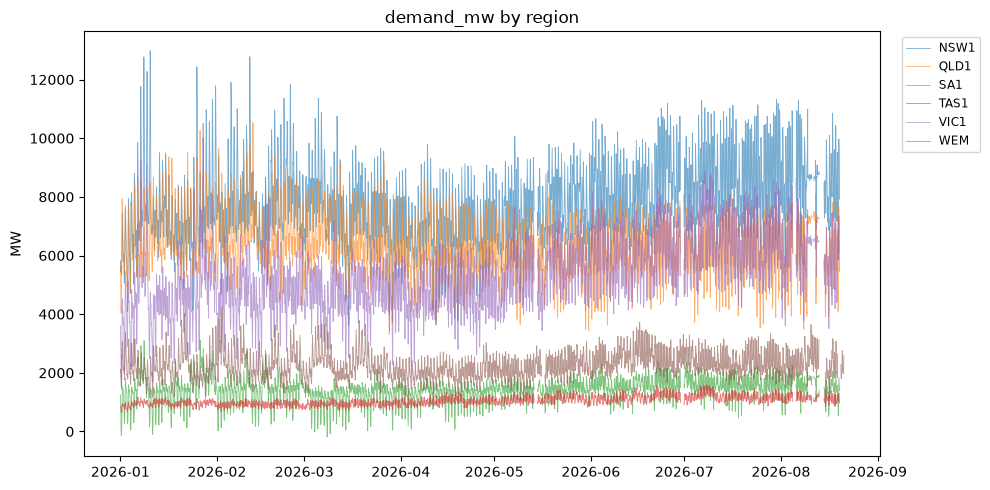

In [61]:
import matplotlib.pyplot as plt

TARGET_COLUMN = "demand_mw"
fig, ax = plt.subplots(figsize=(10, 5))

for region, group in raw_df.groupby("region"):
    ax.plot(
        group["ts"],
        group[TARGET_COLUMN],
        label=region,
        linewidth=0.6,
        alpha=0.6,  # Transparency helps dense regions
    )

ax.set_title(f"{TARGET_COLUMN} by region")
ax.set_ylabel("MW")
# Move legend outside or make it smaller if there are many regions
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small")
fig.tight_layout()

## Step 4 -- Feature engineering

`build_features` (`app/service/ml/features.py`) adds the lag/rolling/calendar columns
`FEATURE_COLUMNS` lists -- the same feature set the live-warehouse training path builds,
just run here against DuckDB-sourced rows instead.


In [ ]:
import numpy as np
import pandas as pd

ALL_MODEL_REGIONS = ["NSW1", "QLD1", "VIC1", "SA1", "TAS1", "WEM"]
TARGET_COLUMN = "demand_mw"
_LAGS = (1, 2, 3, 6, 12)
_ROLLING_WINDOWS = (6, 12, 24)

# `df` (build_master_panel's output, Step 2 above) is the wide panel with
# source-prefixed columns (aemo_demand_mw/oe_demand_mw/aemo_price_mwh/
# oe_total_generation_mw/...) -- resolve the single names this preview (and
# the real `build_features` port in Step 5-6) both expect. Matches
# app/service/ml/demand_data_offline.py's precedent: AEMO's own demand_mw/
# price_mwh are used (not OpenElectricity's parallel columns);
# total_generation_mw/total_renewable_mw only exist on the OpenElectricity
# side (AEMO's own columns have no renewable breakdown).
_COLUMN_RESOLUTION = {
    "demand_mw": "aemo_demand_mw",
    "price_mwh": "aemo_price_mwh",
    "total_generation_mw": "oe_total_generation_mw",
    "total_renewable_mw": "oe_total_renewable_mw",
}


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """Quick preview only -- Step 5-6 below redefines `build_features` with
    the real ported implementation (`app/service/ml/features.py`) that
    `train_model` actually trains against; this trimmed version exists just
    to give Step 3/4's missingness check something real to look at."""
    out = df.rename(columns={"bucket_ts": "ts"}).copy()
    out["ts"] = pd.to_datetime(out["ts"])
    for resolved, source in _COLUMN_RESOLUTION.items():
        if resolved not in out.columns and source in out.columns:
            out[resolved] = out[source]

    ts = out["ts"]
    out["hour"], out["day_of_week"], out["month"] = ts.dt.hour, ts.dt.dayofweek, ts.dt.month
    out["is_weekend"] = ts.dt.weekday >= 5
    out["is_holiday"] = out["is_holiday"].astype(bool)
    for col, period in (("hour", 24), ("day_of_week", 7), ("month", 12)):
        radians = 2 * np.pi * out[col] / period
        out[f"{col}_sin"], out[f"{col}_cos"] = np.sin(radians), np.cos(radians)

    out["heating_degrees"] = (18.3 - out["temp_c"]).clip(lower=0)
    out["cooling_degrees"] = (out["temp_c"] - 18.3).clip(lower=0)
    out["apparent_temp_deviation_c"] = out["apparent_temp_c"] - out["temp_c"]

    total_demand = out.groupby("ts")["demand_mw"].transform("sum")
    out["total_demand_all_regions_mw"] = total_demand
    out["demand_share_of_total"] = out["demand_mw"] / total_demand

    region_dummies = pd.get_dummies(out["region"], prefix="region", dtype=int).reindex(
        columns=[f"region_{code}" for code in ALL_MODEL_REGIONS], fill_value=0
    )
    out = out.join(region_dummies)

    out = out.sort_values(["region", "ts"])
    group = out.groupby("region")[TARGET_COLUMN]
    for lag in _LAGS:
        out[f"{TARGET_COLUMN}_lag_{lag}"] = group.shift(lag)
    for window in _ROLLING_WINDOWS:
        rolling = group.shift(1).rolling(window)
        out[f"{TARGET_COLUMN}_rolling_mean_{window}"] = rolling.mean().reset_index(0, drop=True)
        out[f"{TARGET_COLUMN}_rolling_std_{window}"] = rolling.std().reset_index(0, drop=True)
    return out


FEATURE_COLUMNS: tuple[str, ...] = (
    ("demand_mw", "price_mwh", "total_generation_mw", "total_renewable_mw",
     "temp_c", "apparent_temp_c", "humidity_pct", "wind_speed_kmh",
     "hour", "day_of_week", "month", "is_weekend", "is_holiday",
     "hour_sin", "hour_cos", "day_of_week_sin", "day_of_week_cos", "month_sin", "month_cos",
     "heating_degrees", "cooling_degrees", "apparent_temp_deviation_c",
     "total_demand_all_regions_mw", "demand_share_of_total")
    + tuple(f"region_{code}" for code in ALL_MODEL_REGIONS)
    + tuple(f"{TARGET_COLUMN}_lag_{lag}" for lag in _LAGS)
    + tuple(f"{TARGET_COLUMN}_rolling_{stat}_{window}" for window in _ROLLING_WINDOWS for stat in ("mean", "std"))
)

engineered = build_features(df)
engineered.head()

In [63]:
print(f"engineered: {engineered.shape}  ({len(FEATURE_COLUMNS)} feature columns)")
engineered[list(FEATURE_COLUMNS)].isna().mean().sort_values(ascending=False).head(8)

engineered: (274128, 80)  (41 feature columns)


total_generation_mw          0.227255
total_renewable_mw           0.227255
demand_mw_rolling_std_24     0.049699
demand_mw_rolling_mean_24    0.049699
demand_mw_rolling_std_12     0.047711
demand_mw_rolling_mean_12    0.047711
price_mwh                    0.047004
demand_mw_rolling_std_6      0.046617
dtype: float64

In [64]:
# Real, verbatim ports of ConformalCalibration/fit_conformal/
# empirical_coverage (app/service/ml/conformal.py), DemandBiasCorrection
# (app/service/ml/bias_correction.py), and TrainConfig/TrainResult
# (app/service/ml/train.py) -- fully self-contained, no `from app...`
# imports, so this notebook runs standalone (e.g. in Google Colab)
# without services/forecast-api's own package installed.
from __future__ import annotations

from dataclasses import dataclass, field

import numpy as np
import pandas as pd


DEFAULT_ALPHA = 0.2  # miscoverage target for a P10-P90 (80%) interval


@dataclass
class ConformalCalibration:
    """`q`: shape `(horizon,)` -- the per-horizon-step widening computed by
    `fit_conformal`."""

    q: np.ndarray
    alpha: float

    def apply(self, lo: np.ndarray, hi: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        return lo - self.q, hi + self.q

    def to_dict(self) -> dict[str, object]:
        return {"q": self.q.tolist(), "alpha": self.alpha}

    @classmethod
    def from_dict(cls, data: dict[str, object]) -> ConformalCalibration:
        return cls(q=np.array(data["q"], dtype=np.float64), alpha=float(data["alpha"]))  # type: ignore[arg-type]


def fit_conformal(
    y_cal: np.ndarray,
    lo_cal: np.ndarray,
    hi_cal: np.ndarray,
    alpha: float = DEFAULT_ALPHA,
) -> ConformalCalibration:
    """Conformalized quantile regression (Romano, Patterson & Cand\u00e8s, 2019).
    `y_cal`/`lo_cal`/`hi_cal`: shape `(n_samples, horizon)` -- the true
    target and the model's raw P10/P90 on a held-out calibration split."""
    if not (y_cal.shape == lo_cal.shape == hi_cal.shape):
        raise ValueError(
            "y_cal/lo_cal/hi_cal must all share the same (n_samples, horizon) shape"
        )
    n = y_cal.shape[0]
    if n < 2:
        raise ValueError("need at least 2 calibration samples")
    scores = np.maximum(lo_cal - y_cal, y_cal - hi_cal)
    level = min(1.0, np.ceil((1 - alpha) * (n + 1)) / n)
    q = np.quantile(scores, level, axis=0, method="higher")
    return ConformalCalibration(q=np.asarray(q, dtype=np.float64), alpha=alpha)


def empirical_coverage(y: np.ndarray, lo: np.ndarray, hi: np.ndarray) -> float:
    """Fraction of `y` values that actually fall within `[lo, hi]`."""
    return float(np.mean((y >= lo) & (y <= hi)))


@dataclass
class DemandBiasCorrection:
    """`bias_by_region[region]`: shape `(horizon,)`, real `mean(actual -
    p50)` MW over that region's own calibration split."""

    bias_by_region: dict[str, np.ndarray] = field(default_factory=dict)

    def apply(
        self, region: str, p10: np.ndarray, p50: np.ndarray, p90: np.ndarray
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        bias = self.bias_by_region.get(region)
        if bias is None:
            return p10, p50, p90
        return p10 + bias, p50 + bias, p90 + bias

    def to_dict(self) -> dict[str, list[float]]:
        return {region: arr.tolist() for region, arr in self.bias_by_region.items()}

    @classmethod
    def from_dict(cls, data: dict[str, list[float]]) -> DemandBiasCorrection:
        return cls(
            bias_by_region={
                region: np.array(vals, dtype=np.float64) for region, vals in data.items()
            }
        )


@dataclass
class TrainConfig:
    lookback: int = 24
    horizon: int = 48
    hidden_size: int = 128
    num_layers: int = 2
    dropout: float = 0.25
    weight_decay: float = 1e-5
    lr: float = 1e-3
    epochs: int = 50
    batch_size: int = 64
    quantile_weight: float = 1.0
    conformal_alpha: float = 0.2
    cal_frac: float = 0.5
    early_stopping_patience: int = 5
    train_frac: float = 0.49
    val_frac: float = 0.49

    train_start: pd.Timestamp | None = None
    train_end: pd.Timestamp | None = None
    val_start: pd.Timestamp | None = None
    val_end: pd.Timestamp | None = None
    test_start: pd.Timestamp | None = None
    test_end: pd.Timestamp | None = None

    shuffle: bool = True

    @classmethod
    def from_settings(cls) -> TrainConfig:
        # Real production defaults (app/core/config.py's Settings), with
        # epochs dialed down for a fast first pass in this notebook --
        # bump it back up (e.g. 50) for a real run.
        return cls(
            lookback=24,
            horizon=48,
            hidden_size=128,
            num_layers=2,
            dropout=0.25,
            weight_decay=1e-5,
            lr=1e-3,
            epochs=10,
            batch_size=32,
            quantile_weight=1.0,
            conformal_alpha=0.2,
            cal_frac=0.5,
            early_stopping_patience=5,
        )


@dataclass
class TrainResult:
    model: "nn.Module"
    calibration: ConformalCalibration
    bias_correction: DemandBiasCorrection
    feature_scalers: dict
    target_scaler: dict
    history: list[dict[str, float]] = field(default_factory=list)
    test_metrics: dict[str, float] = field(default_factory=dict)
    n_train_windows: int = 0
    n_val_windows: int = 0
    n_cal_windows: int = 0
    n_test_windows: int = 0


In [ ]:
# Real, verbatim ports of app/models/ml.py (DemandLSTM),
# app/service/ml/features.py (build_features), app/service/ml/data.py
# (DemandDataset/scalers/splits), app/service/ml/losses.py (demand_loss),
# app/service/ml/device.py (get_device), and app/service/ml/train.py
# (train_model + its private helpers) -- fully self-contained, no
# `from app...` imports, so this cell (and the whole notebook) runs
# standalone in Google Colab. `structlog` is replaced by a tiny
# print-based stub (`log`) -- the real code only ever used it for
# progress logging, never for control flow.
from __future__ import annotations

import tempfile
from collections.abc import Callable, Sequence
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_pinball_loss,
    root_mean_squared_error,
)
from sklearn.preprocessing import StandardScaler
from torch import Tensor, nn
from torch.utils.data import ConcatDataset, DataLoader, Dataset


class _Log:
    def info(self, event, **kwargs):
        print(f"[info] {event} {kwargs}")

    def warning(self, event, **kwargs):
        print(f"[warning] {event} {kwargs}")


log = _Log()


# ── app/models/ml.py ──────────────────────────────────────────────────
@dataclass
class DemandForecast:
    """One forward pass's output -- each field shaped `(batch, horizon)`."""

    p10: Tensor
    p50: Tensor
    p90: Tensor


class AttentionPool(nn.Module):
    def __init__(self, hidden_size: int) -> None:
        super().__init__()
        self.score = nn.Linear(hidden_size, 1)

    def forward(self, lstm_out: Tensor) -> Tensor:
        scores = self.score(lstm_out).squeeze(-1)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)
        return (lstm_out * weights).sum(dim=1)


class DemandLSTM(nn.Module):
    def __init__(
        self,
        n_features: int,
        horizon: int = 48,
        hidden_size: int = 128,
        num_layers: int = 2,
        dropout: float = 0.2,
    ) -> None:
        super().__init__()
        self.n_features = n_features
        self.horizon = horizon
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True,
        )
        self.attention = AttentionPool(hidden_size)
        self.head_dropout = nn.Dropout(dropout)
        self.point_head = nn.Linear(hidden_size, horizon)
        self.lower_spread_head = nn.Linear(hidden_size, horizon)
        self.upper_spread_head = nn.Linear(hidden_size, horizon)

    def forward(self, x: Tensor) -> DemandForecast:
        lstm_out, _ = self.lstm(x)
        context = self.head_dropout(self.attention(lstm_out))
        p50 = self.point_head(context)
        lower_spread = torch.nn.functional.softplus(self.lower_spread_head(context))
        upper_spread = torch.nn.functional.softplus(self.upper_spread_head(context))
        return DemandForecast(p10=p50 - lower_spread, p50=p50, p90=p50 + upper_spread)


# ── app/service/ml/device.py ────────────────────────────────────────────
def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


# ── app/service/ml/losses.py ────────────────────────────────────────────
def pinball_loss(pred: Tensor, target: Tensor, quantile: float) -> Tensor:
    error = target - pred
    return torch.maximum(quantile * error, (quantile - 1) * error).mean()


def demand_loss(forecast: DemandForecast, target: Tensor, *, quantile_weight: float = 1.0) -> Tensor:
    point = pinball_loss(forecast.p50, target, 0.5)
    lower = pinball_loss(forecast.p10, target, 0.1)
    upper = pinball_loss(forecast.p90, target, 0.9)
    return point + quantile_weight * (lower + upper)


# ── app/service/ml/features.py ──────────────────────────────────────────
TARGET_COLUMN = "demand_mw"
_LAGS: tuple[int, ...] = (1, 2, 3, 6, 12)
_ROLLING_WINDOWS: tuple[int, ...] = (6, 12, 24)
_COMFORT_TEMP_C = 18.0
ALL_MODEL_REGIONS: tuple[str, ...] = ("NSW1", "QLD1", "VIC1", "SA1", "TAS1", "WEM")


def add_cyclical(df: pd.DataFrame, col: str, period: float) -> pd.DataFrame:
    out = df.copy()
    radians = 2 * np.pi * out[col].astype(float) / period
    out[f"{col}_sin"] = np.sin(radians)
    out[f"{col}_cos"] = np.cos(radians)
    return out


def add_calendar_features(
    df: pd.DataFrame, ts_col: str = "ts", holidays: pd.DataFrame | None = None
) -> pd.DataFrame:
    out = df.copy()
    ts = pd.to_datetime(out[ts_col], utc=True)
    out["hour"] = ts.dt.hour
    out["day_of_week"] = ts.dt.dayofweek
    out["month"] = ts.dt.month
    out["is_weekend"] = out["day_of_week"].isin([5, 6])

    if holidays is not None and not holidays.empty:
        holiday_dates = pd.to_datetime(holidays["date"]).dt.date
        if "region" in holidays.columns and "region" in out.columns:
            pairs = set(zip(holidays["region"], holiday_dates, strict=True))
            out["is_holiday"] = [
                (r, d) in pairs for r, d in zip(out["region"], ts.dt.date, strict=True)
            ]
        else:
            out["is_holiday"] = ts.dt.date.isin(set(holiday_dates))
    else:
        out["is_holiday"] = False

    for col, period in (("hour", 24), ("day_of_week", 7), ("month", 12)):
        out = add_cyclical(out, col, period)
    return out


def add_lag_and_rolling(
    df: pd.DataFrame,
    target_col: str = TARGET_COLUMN,
    lags: Sequence[int] = _LAGS,
    windows: Sequence[int] = _ROLLING_WINDOWS,
    group_col: str = "region",
    ts_col: str = "ts",
) -> pd.DataFrame:
    out = df.sort_values([group_col, ts_col]).reset_index(drop=True)
    grouped_target = out.groupby(group_col, sort=False)[target_col]
    for lag in lags:
        out[f"{target_col}_lag_{lag}"] = grouped_target.shift(lag)
    for window in windows:
        out[f"{target_col}_rolling_mean_{window}"] = grouped_target.transform(
            lambda s, w=window: s.shift(1).rolling(w, min_periods=1).mean()
        )
        out[f"{target_col}_rolling_std_{window}"] = grouped_target.transform(
            lambda s, w=window: s.shift(1).rolling(w, min_periods=1).std()
        )
    return out


def add_weather_derived(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "temp_c" in out.columns:
        out["heating_degrees"] = (_COMFORT_TEMP_C - out["temp_c"]).clip(lower=0)
        out["cooling_degrees"] = (out["temp_c"] - _COMFORT_TEMP_C).clip(lower=0)
        if "apparent_temp_c" in out.columns:
            out["apparent_temp_deviation_c"] = out["apparent_temp_c"] - out["temp_c"]
    return out


def add_cross_region_context(
    df: pd.DataFrame, target_col: str = TARGET_COLUMN, group_col: str = "region", ts_col: str = "ts"
) -> pd.DataFrame:
    out = df.copy()
    total_by_ts = out.groupby(ts_col)[target_col].transform("sum")
    out["total_demand_all_regions_mw"] = total_by_ts
    out["demand_share_of_total"] = out[target_col] / total_by_ts.replace(0, np.nan)
    return out


def add_region_dummies(
    df: pd.DataFrame, regions: Sequence[str] = ALL_MODEL_REGIONS, group_col: str = "region"
) -> pd.DataFrame:
    dummies = pd.get_dummies(df[group_col], prefix="region", dtype=float).reindex(
        columns=[f"region_{code}" for code in regions], fill_value=0.0
    )
    return df.join(dummies)


def build_features(df: pd.DataFrame, holidays: pd.DataFrame | None = None) -> pd.DataFrame:
    out = add_calendar_features(df, holidays=holidays)
    out = add_weather_derived(out)
    out = add_cross_region_context(out)
    out = add_region_dummies(out)
    out = add_lag_and_rolling(out)
    return out


_RAW_CONTEXT_COLUMNS: tuple[str, ...] = (
    "price_mwh", "total_generation_mw", "total_renewable_mw",
    "temp_c", "apparent_temp_c", "humidity_pct", "wind_speed_kmh",
)
_CALENDAR_FLAG_COLUMNS: tuple[str, ...] = ("is_weekend", "is_holiday")
_CALENDAR_CYCLICAL_COLUMNS: tuple[str, ...] = (
    "hour_sin", "hour_cos", "day_of_week_sin", "day_of_week_cos", "month_sin", "month_cos",
)
_WEATHER_DERIVED_COLUMNS: tuple[str, ...] = (
    "heating_degrees", "cooling_degrees", "apparent_temp_deviation_c",
)
_CROSS_REGION_COLUMNS: tuple[str, ...] = ("total_demand_all_regions_mw", "demand_share_of_total")
_REGION_COLUMNS: tuple[str, ...] = tuple(f"region_{code}" for code in ALL_MODEL_REGIONS)
_LAG_COLUMNS: tuple[str, ...] = tuple(f"{TARGET_COLUMN}_lag_{lag}" for lag in _LAGS)
_ROLLING_COLUMNS: tuple[str, ...] = tuple(
    f"{TARGET_COLUMN}_rolling_{stat}_{window}" for window in _ROLLING_WINDOWS for stat in ("mean", "std")
)

FEATURE_COLUMNS: tuple[str, ...] = (
    _RAW_CONTEXT_COLUMNS + _CALENDAR_FLAG_COLUMNS + _CALENDAR_CYCLICAL_COLUMNS
    + _WEATHER_DERIVED_COLUMNS + _CROSS_REGION_COLUMNS + _REGION_COLUMNS
    + _LAG_COLUMNS + _ROLLING_COLUMNS
)
NUMERIC_COLUMNS: tuple[str, ...] = (
    _RAW_CONTEXT_COLUMNS + _WEATHER_DERIVED_COLUMNS + _CROSS_REGION_COLUMNS
    + _LAG_COLUMNS + _ROLLING_COLUMNS
)
KNOWN_FUTURE_COLUMNS: tuple[str, ...] = _CALENDAR_FLAG_COLUMNS + _CALENDAR_CYCLICAL_COLUMNS + _REGION_COLUMNS
OBSERVED_PAST_COLUMNS: tuple[str, ...] = tuple(c for c in FEATURE_COLUMNS if c not in KNOWN_FUTURE_COLUMNS)


# ── app/service/ml/data.py ──────────────────────────────────────────────
@dataclass
class TimeSplit:
    train: pd.DataFrame
    val: pd.DataFrame
    test: pd.DataFrame


def split_by_time(
    df: pd.DataFrame, ts_col: str = "ts", train_frac: float = 0.7, val_frac: float = 0.15
) -> TimeSplit:
    if not (0 < train_frac < 1) or not (0 < val_frac < 1) or train_frac + val_frac >= 1:
        raise ValueError("train_frac/val_frac must each be in (0, 1) and sum to < 1")
    unique_ts = np.sort(df[ts_col].unique())
    n = len(unique_ts)
    train_end = unique_ts[max(0, int(n * train_frac) - 1)]
    val_end = unique_ts[max(0, int(n * (train_frac + val_frac)) - 1)]
    train = df[df[ts_col] <= train_end]
    val = df[(df[ts_col] > train_end) & (df[ts_col] <= val_end)]
    test = df[df[ts_col] > val_end]
    return TimeSplit(train=train, val=val, test=test)


def split_by_date(
    df: pd.DataFrame, *, train_start, train_end, val_start, val_end, test_start, test_end, ts_col: str = "ts"
) -> TimeSplit:
    train = df[(df[ts_col] >= train_start) & (df[ts_col] <= train_end)]
    val = df[(df[ts_col] >= val_start) & (df[ts_col] <= val_end)]
    test = df[(df[ts_col] >= test_start) & (df[ts_col] <= test_end)]
    return TimeSplit(train=train, val=val, test=test)


def fit_scalers(
    train: pd.DataFrame, group_col: str = "region", columns: Sequence[str] = NUMERIC_COLUMNS
) -> dict[str, StandardScaler]:
    columns = list(columns)
    scalers: dict[str, StandardScaler] = {}
    for region, group in train.groupby(group_col):
        clean = group[columns].dropna()
        if clean.empty:
            continue
        scaler = StandardScaler()
        scaler.fit(clean.to_numpy())
        scalers[region] = scaler
    return scalers


def apply_scalers(
    df: pd.DataFrame, scalers: dict[str, StandardScaler], group_col: str = "region",
    columns: Sequence[str] = NUMERIC_COLUMNS,
) -> pd.DataFrame:
    out = df.copy()
    columns = list(columns)
    for region, scaler in scalers.items():
        mask = out[group_col] == region
        if not mask.any():
            continue
        values = out.loc[mask, columns]
        scalable = values.index[values.notna().all(axis=1)]
        if len(scalable) == 0:
            continue
        out.loc[scalable, columns] = scaler.transform(out.loc[scalable, columns].to_numpy())
    return out


class DemandDataset(Dataset):
    def __init__(
        self, df: pd.DataFrame, feature_columns: Sequence[str] = FEATURE_COLUMNS,
        target_col: str = TARGET_COLUMN, lookback: int = 48, horizon: int = 48,
        group_col: str = "region", ts_col: str = "ts", min_target_ts=None,
    ) -> None:
        self.feature_columns = list(feature_columns)
        self.target_col = target_col
        self.lookback = lookback
        self.horizon = horizon
        self._samples: list[tuple[np.ndarray, np.ndarray]] = []
        sorted_df = df.sort_values([group_col, ts_col])
        window_span = lookback + horizon
        for _, group in sorted_df.groupby(group_col, sort=False):
            features = group[self.feature_columns].to_numpy(dtype=np.float32)
            target = group[self.target_col].to_numpy(dtype=np.float32)
            timestamps = group[ts_col].to_numpy()
            for start in range(len(group) - window_span + 1):
                if min_target_ts is not None and timestamps[start + lookback] <= min_target_ts:
                    continue
                x = features[start : start + lookback]
                y = target[start + lookback : start + window_span]
                if np.isnan(x).any() or np.isnan(y).any():
                    continue
                self._samples.append((x.copy(), y.copy()))

    def __len__(self) -> int:
        return len(self._samples)

    def __getitem__(self, index: int) -> tuple[Tensor, Tensor]:
        x, y = self._samples[index]
        return torch.from_numpy(x), torch.from_numpy(y)


def collate(batch: Sequence[tuple[Tensor, Tensor]]) -> tuple[Tensor, Tensor]:
    xs, ys = zip(*batch, strict=True)
    return torch.stack(xs), torch.stack(ys)


# ── app/service/ml/train.py ─────────────────────────────────────────────
def state_dict_bytes(model: nn.Module) -> int:
    with tempfile.TemporaryDirectory() as tmpdir:
        p = Path(tmpdir) / "model_state_dict.pt"
        torch.save(model.state_dict(), p)
        return p.stat().st_size


# mape/rmse/mae wrap sklearn.metrics' builtins rather than reimplementing
# the formulas -- mape keeps its zero-target mask (sklearn's own MAPE has
# no such guard and would otherwise blow up on a demand_mw==0 row).
def mape(pred: np.ndarray, target: np.ndarray) -> float:
    mask = target != 0
    if not mask.any():
        return float("nan")
    return float(mean_absolute_percentage_error(target[mask], pred[mask]) * 100)


def rmse(pred: np.ndarray, target: np.ndarray) -> float:
    return float(root_mean_squared_error(target, pred))


def mae(pred: np.ndarray, target: np.ndarray) -> float:
    return float(mean_absolute_error(target, pred))


def _fit_target_scaler(
    train: pd.DataFrame, target_col: str = TARGET_COLUMN, group_col: str = "region"
) -> dict[str, StandardScaler]:
    scalers: dict[str, StandardScaler] = {}
    for region, group in train.groupby(group_col):
        clean = group[[target_col]].dropna()
        if clean.empty:
            continue
        scaler = StandardScaler()
        scaler.fit(clean.to_numpy())
        scalers[region] = scaler
    return scalers


def _scale_target(
    df: pd.DataFrame, scalers: dict[str, StandardScaler], target_col: str = TARGET_COLUMN, group_col: str = "region"
) -> pd.DataFrame:
    out = df.copy()
    for region, scaler in scalers.items():
        mask = (out[group_col] == region) & out[target_col].notna()
        if not mask.any():
            continue
        out.loc[mask, target_col] = scaler.transform(out.loc[mask, [target_col]].to_numpy()).ravel()
    return out


def _inverse_target(scaler: StandardScaler, values: np.ndarray) -> np.ndarray:
    shape = values.shape
    return scaler.inverse_transform(values.reshape(-1, 1)).reshape(shape)


def _split_val_for_calibration(
    val: pd.DataFrame, cal_frac: float, ts_col: str = "ts"
) -> tuple[pd.DataFrame, pd.DataFrame]:
    unique_ts = np.sort(val[ts_col].unique())
    n = len(unique_ts)
    if n < 2:
        return val, val.iloc[0:0]
    boundary_idx = max(0, int(n * (1 - cal_frac)) - 1)
    boundary = unique_ts[boundary_idx]
    return val[val[ts_col] <= boundary], val[val[ts_col] > boundary]


def _predict(model: DemandLSTM, loader: DataLoader, device: torch.device):
    model.eval()
    ys, p10s, p50s, p90s = [], [], [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            ys.append(y.cpu().numpy())
            p10s.append(out.p10.cpu().numpy())
            p50s.append(out.p50.cpu().numpy())
            p90s.append(out.p90.cpu().numpy())
    return (np.concatenate(ys), np.concatenate(p10s), np.concatenate(p50s), np.concatenate(p90s))


def _predict_regions_mw(
    model: DemandLSTM, region_datasets: dict[str, DemandDataset],
    target_scalers: dict[str, StandardScaler], config: TrainConfig, device: torch.device,
):
    ys, p10s, p50s, p90s = [], [], [], []
    for region, ds in region_datasets.items():
        scaler = target_scalers.get(region)
        if len(ds) == 0 or scaler is None:
            continue
        loader = DataLoader(ds, batch_size=config.batch_size, shuffle=False, collate_fn=collate)
        y, p10, p50, p90 = _predict(model, loader, device)
        ys.append(_inverse_target(scaler, y))
        p10s.append(_inverse_target(scaler, p10))
        p50s.append(_inverse_target(scaler, p50))
        p90s.append(_inverse_target(scaler, p90))
    return (np.concatenate(ys), np.concatenate(p10s), np.concatenate(p50s), np.concatenate(p90s))


def _compute_val_loss(model: DemandLSTM, loader: DataLoader, quantile_weight: float, device: torch.device) -> float:
    model.eval()
    losses = []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = demand_loss(out, y, quantile_weight=quantile_weight)
            losses.append(loss.item())
    return float(np.mean(losses))


def train_model(
    raw_df: pd.DataFrame,
    config: TrainConfig,
    *,
    holidays: pd.DataFrame | None = None,
    warm_start_state_dict: dict[str, torch.Tensor] | None = None,
    epoch_callback: Callable[[int, dict[str, float]], None] | None = None,
) -> TrainResult:
    engineered = build_features(raw_df, holidays=holidays)

    use_date_split = config.train_start is not None
    per_region_split: dict[str, tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]] = {}
    for region, region_df in engineered.groupby("region"):
        if use_date_split:
            region_split = split_by_date(
                region_df, train_start=config.train_start, train_end=config.train_end,
                val_start=config.val_start, val_end=config.val_end,
                test_start=config.test_start, test_end=config.test_end,
            )
        else:
            region_split = split_by_time(region_df, train_frac=config.train_frac, val_frac=config.val_frac)
        region_earlystop_val, region_cal = _split_val_for_calibration(region_split.val, config.cal_frac)
        per_region_split[region] = (region_split.train, region_earlystop_val, region_cal)

    split_train = pd.concat([t for t, _, _ in per_region_split.values()])
    earlystop_val = pd.concat([v for _, v, _ in per_region_split.values()])
    cal = pd.concat([c for _, _, c in per_region_split.values()])

    if split_train.empty or earlystop_val.empty or cal.empty:
        raise ValueError(
            "not enough history to build train/val/calibration splits "
            f"(lookback={config.lookback}, horizon={config.horizon}) -- "
            f"got {len(split_train)}/{len(earlystop_val)}/{len(cal)} rows"
        )

    scalers = fit_scalers(split_train)
    full_scaled = apply_scalers(engineered, scalers)

    target_scaler = _fit_target_scaler(split_train)
    full_scaled = _scale_target(full_scaled, target_scaler)

    train_parts, val_parts, cal_parts, test_parts = [], [], [], []
    region_window_counts: dict[str, tuple[int, int, int]] = {}
    region_cal_datasets: dict[str, DemandDataset] = {}
    region_val_datasets: dict[str, DemandDataset] = {}
    region_test_datasets: dict[str, DemandDataset] = {}
    for region, (region_train, region_earlystop_val, region_cal) in per_region_split.items():
        if region_train.empty or region_earlystop_val.empty or region_cal.empty:
            log.warning(
                "train_model.region_split_empty", region=region, n_train=len(region_train),
                n_earlystop_val=len(region_earlystop_val), n_cal=len(region_cal),
            )
            region_window_counts[region] = (0, 0, 0)
            continue

        region_full = full_scaled[full_scaled["region"] == region]
        region_train_end = region_train["ts"].max()
        region_val_end = pd.concat([region_earlystop_val, region_cal])["ts"].max()
        region_cal_boundary = region_earlystop_val["ts"].max()

        region_train_ds = DemandDataset(
            region_full[region_full["ts"] <= region_train_end], lookback=config.lookback, horizon=config.horizon,
        )
        region_val_ds = DemandDataset(
            region_full[region_full["ts"] <= region_cal_boundary], lookback=config.lookback,
            horizon=config.horizon, min_target_ts=region_train_end,
        )
        region_cal_ds = DemandDataset(
            region_full[region_full["ts"] <= region_val_end], lookback=config.lookback,
            horizon=config.horizon, min_target_ts=region_cal_boundary,
        )
        region_test_input = (
            region_full[region_full["ts"] <= config.test_end] if use_date_split else region_full
        )
        region_test_ds = DemandDataset(
            region_test_input, lookback=config.lookback, horizon=config.horizon, min_target_ts=region_val_end,
        )
        region_window_counts[region] = (len(region_train_ds), len(region_val_ds), len(region_cal_ds))
        train_parts.append(region_train_ds)
        val_parts.append(region_val_ds)
        cal_parts.append(region_cal_ds)
        test_parts.append(region_test_ds)
        region_cal_datasets[region] = region_cal_ds
        region_val_datasets[region] = region_val_ds
        region_test_datasets[region] = region_test_ds

    log.info("train_model.region_window_counts", counts=region_window_counts)

    train_ds: ConcatDataset = ConcatDataset(train_parts)
    val_ds: ConcatDataset = ConcatDataset(val_parts)
    cal_ds: ConcatDataset = ConcatDataset(cal_parts)
    test_ds: ConcatDataset = ConcatDataset(test_parts)

    if len(train_ds) == 0 or len(val_ds) == 0 or len(cal_ds) == 0:
        raise ValueError(
            "not enough history to build train/val/calibration windows "
            f"(lookback={config.lookback}, horizon={config.horizon}) -- "
            f"got {len(train_ds)}/{len(val_ds)}/{len(cal_ds)} windows ({region_window_counts})"
        )

    train_loader = DataLoader(train_ds, batch_size=config.batch_size, shuffle=config.shuffle, collate_fn=collate)
    val_loader = DataLoader(val_ds, batch_size=config.batch_size, shuffle=False, collate_fn=collate)
    test_loader = (
        DataLoader(test_ds, batch_size=config.batch_size, shuffle=False, collate_fn=collate)
        if len(test_ds) > 0 else None
    )

    device = get_device()
    model = DemandLSTM(
        n_features=len(FEATURE_COLUMNS), horizon=config.horizon, hidden_size=config.hidden_size,
        num_layers=config.num_layers, dropout=config.dropout,
    )
    if warm_start_state_dict is not None:
        model.load_state_dict(warm_start_state_dict)
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=2)

    best_val_mape = float("inf")
    best_state: dict[str, torch.Tensor] | None = None
    patience_counter = 0
    history: list[dict[str, float]] = []

    for epoch in range(config.epochs):
        model.train()
        train_losses = []
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = demand_loss(out, y, quantile_weight=config.quantile_weight)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())

        y_val_mw, _, p50_val_mw, _ = _predict_regions_mw(model, region_val_datasets, target_scaler, config, device)
        val_mape = mape(p50_val_mw, y_val_mw)
        val_rmse = rmse(p50_val_mw, y_val_mw)
        val_mae = mae(p50_val_mw, y_val_mw)
        val_loss = _compute_val_loss(model, val_loader, config.quantile_weight, device)
        scheduler.step(val_mape)

        history.append({
            "epoch": float(epoch), "train_loss": float(np.mean(train_losses)),
            "val_loss": val_loss, "val_mape": val_mape, "val_rmse": val_rmse, "val_mae": val_mae,
        })
        log.info(
            "train.epoch", epoch=epoch, train_loss=history[-1]["train_loss"],
            val_loss=val_loss, val_mape=val_mape, val_rmse=val_rmse, val_mae=val_mae,
        )
        if epoch_callback is not None:
            epoch_callback(epoch, history[-1])

        if val_mape < best_val_mape - 1e-4:
            best_val_mape = val_mape
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= config.early_stopping_patience:
                log.info("train.early_stop", epoch=epoch, best_val_mape=best_val_mape)
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    bias_by_region: dict[str, np.ndarray] = {}
    y_cal_parts: list[np.ndarray] = []
    p10_cal_parts: list[np.ndarray] = []
    p90_cal_parts: list[np.ndarray] = []
    for region, region_cal_ds in region_cal_datasets.items():
        region_scaler = target_scaler.get(region)
        if len(region_cal_ds) == 0 or region_scaler is None:
            continue
        region_cal_loader = DataLoader(region_cal_ds, batch_size=config.batch_size, shuffle=False, collate_fn=collate)
        y_region, p10_region, p50_region, p90_region = _predict(model, region_cal_loader, device)
        y_region = _inverse_target(region_scaler, y_region)
        p10_region = _inverse_target(region_scaler, p10_region)
        p50_region = _inverse_target(region_scaler, p50_region)
        p90_region = _inverse_target(region_scaler, p90_region)

        region_bias = np.mean(y_region - p50_region, axis=0)
        bias_by_region[region] = region_bias

        y_cal_parts.append(y_region)
        p10_cal_parts.append(p10_region + region_bias)
        p90_cal_parts.append(p90_region + region_bias)

    bias_correction = DemandBiasCorrection(bias_by_region=bias_by_region)
    y_cal = np.concatenate(y_cal_parts)
    p10_cal = np.concatenate(p10_cal_parts)
    p90_cal = np.concatenate(p90_cal_parts)
    calibration = fit_conformal(y_cal, p10_cal, p90_cal, alpha=config.conformal_alpha)

    test_metrics: dict[str, float] = {}
    if test_loader is not None:
        y_test, p10_test, p50_test, p90_test = _predict_regions_mw(
            model, region_test_datasets, target_scaler, config, device
        )
        lo_calibrated, hi_calibrated = calibration.apply(p10_test, p90_test)
        test_metrics = {
            "test_mape": mape(p50_test, y_test),
            "test_coverage_raw": empirical_coverage(y_test, p10_test, p90_test),
            "test_coverage_calibrated": empirical_coverage(y_test, lo_calibrated, hi_calibrated),
            "test_interval_width_raw_mw": float(np.mean(p90_test - p10_test)),
            "test_interval_width_calibrated_mw": float(np.mean(hi_calibrated - lo_calibrated)),
        }

    model.to("cpu")

    return TrainResult(
        model=model, calibration=calibration, bias_correction=bias_correction,
        feature_scalers=scalers, target_scaler=target_scaler, history=history, test_metrics=test_metrics,
        n_train_windows=len(train_ds), n_val_windows=len(val_ds), n_cal_windows=len(cal_ds), n_test_windows=len(test_ds),
    )


In [66]:
config = TrainConfig.from_settings()

# Real (date, region) holiday table, built directly from landed.duckdb --
# no app.service.ml.demand_data_offline import needed. Without this,
# add_calendar_features (inside build_features, inside train_model)
# silently sets is_holiday=False for every row.
with duckdb.connect(str(db_path), read_only=True) as conn:
    holidays_df = conn.execute("SELECT DISTINCT date, region FROM aemo_holidays").fetchdf()
holidays_df["date"] = pd.to_datetime(holidays_df["date"]).dt.date

result = train_model(raw_df, config, holidays=holidays_df)
print(f"windows -- train: {result.n_train_windows}  val: {result.n_val_windows}  "
      f"cal: {result.n_cal_windows}  test: {result.n_test_windows}")


[info] train_model.region_window_counts {'counts': {'NSW1': (2653, 1215, 955), 'QLD1': (2653, 1215, 955), 'SA1': (2653, 1215, 955), 'TAS1': (2653, 1215, 955), 'VIC1': (2653, 1215, 955), 'WEM': (2653, 1214, 1227)}}
[info] train.epoch {'epoch': 0, 'train_loss': 0.5006203863276056, 'val_loss': 0.5790232199718032, 'val_mape': 10.176592826843262, 'val_rmse': 584.617431640625, 'val_mae': 382.0867614746094}
[info] train.epoch {'epoch': 1, 'train_loss': 0.358026425342962, 'val_loss': 0.5589278900440324, 'val_mape': 9.5364990234375, 'val_rmse': 527.2984008789062, 'val_mae': 346.4271240234375}
[info] train.epoch {'epoch': 2, 'train_loss': 0.3119831187538354, 'val_loss': 0.598590292886161, 'val_mape': 9.744117736816406, 'val_rmse': 534.4706420898438, 'val_mae': 353.1377868652344}
[info] train.epoch {'epoch': 3, 'train_loss': 0.28302780903845903, 'val_loss': 0.5977142830951172, 'val_mape': 9.467713356018066, 'val_rmse': 526.7955932617188, 'val_mae': 343.8808898925781}
[info] train.epoch {'epoch': 

test metrics: {'test_mape': 9.188608169555664, 'test_coverage_raw': 0.5913461538461539, 'test_coverage_calibrated': 0.7653133903133903, 'test_interval_width_raw_mw': 703.97216796875, 'test_interval_width_calibrated_mw': 980.2293328722658}


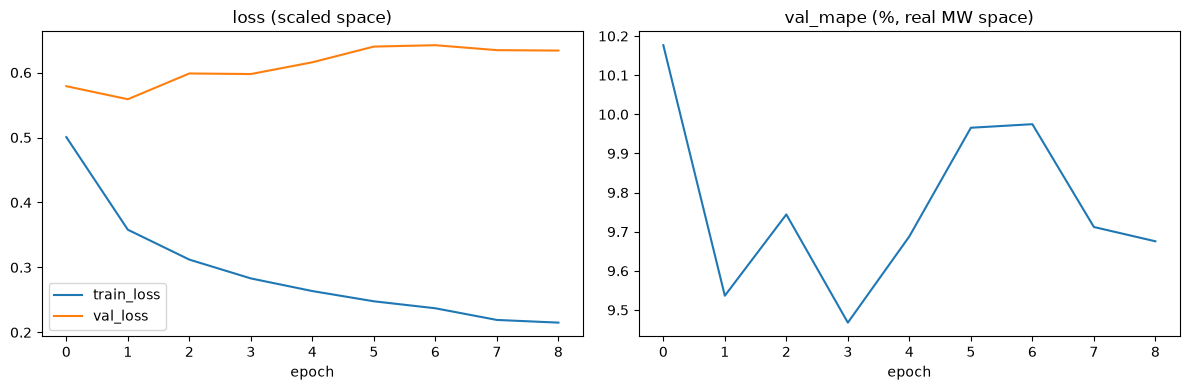

In [67]:
epochs = [h["epoch"] for h in result.history]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(epochs, [h["train_loss"] for h in result.history], label="train_loss")
ax1.plot(epochs, [h["val_loss"] for h in result.history], label="val_loss")
ax1.set_title("loss (scaled space)")
ax1.set_xlabel("epoch")
ax1.legend()

ax2.plot(epochs, [h["val_mape"] for h in result.history])
ax2.set_title("val_mape (%, real MW space)")
ax2.set_xlabel("epoch")
fig.tight_layout()
print(f"test metrics: {result.test_metrics}")


In [68]:
print("Conformal calibration q (per horizon step, MW):", result.calibration.q[:5], "...")
print()
print(f"raw test coverage:        {result.test_metrics.get('test_coverage_raw', float('nan')):.1%}  (target: 80%)")
print(f"calibrated test coverage: {result.test_metrics.get('test_coverage_calibrated', float('nan')):.1%}  (target: 80%)")
print()
print("per-region P50 bias (MW, mean actual - predicted on the calibration split):")
for region, bias in result.bias_correction.bias_by_region.items():
    print(f"  {region}: mean={bias.mean():+.1f} MW")

Conformal calibration q (per horizon step, MW): [54.71679688 63.00244141 61.68359375 80.5234375  94.49859619] ...

raw test coverage:        59.1%  (target: 80%)
calibrated test coverage: 76.5%  (target: 80%)

per-region P50 bias (MW, mean actual - predicted on the calibration split):
  NSW1: mean=+888.3 MW
  QLD1: mean=+78.5 MW
  SA1: mean=+181.0 MW
  TAS1: mean=+184.3 MW
  VIC1: mean=+867.9 MW
  WEM: mean=+251.6 MW


## Step 5.5 -- Hyperparameter tuning with Optuna

Real, verbatim (MLflow-free) port of `tune_optuna` (`app/service/ml/tune.py`) --
the actual Optuna search this platform's `make tune-optuna` / tuning CLI path
runs, not a simplified stand-in. Same search space (`hidden_size`/
`num_layers`/`dropout`/`weight_decay`/`lr`/`batch_size`), same
`optuna.samplers.TPESampler`, and the same `optuna.pruners.MedianPruner`
wired through `train_model`'s own `epoch_callback` hook so a trial trending
worse than the run-so-far median gets stopped mid-training instead of
burning its full epoch budget (standard successive-halving practice, not a
shortcut unique to this notebook). `lookback`/`horizon` are deliberately not
searched -- both are load-bearing for the serving contract, matching the
real `tune.py`'s own `OPTUNA_*` search space exactly.

One deliberate deviation from `tune.py`'s objective: each trial is scored on
its *best* epoch's `val_mape` (`min(h["val_mape"] for h in history)`), not
the *last* one. `train_model` already restores the best-epoch weights via
early stopping (`best_state`) before returning, so scoring the last epoch
instead -- as `tune.py`'s own objective literally does -- can rank a trial
that peaked early then drifted worse below one that never found a good point
at all. Scoring the best epoch judges each trial by the model it actually
hands back.

Each trial trains at a reduced `TUNE_EPOCHS` budget (with `TUNE_PATIENCE`
epochs of patience) as a fast-but-real proxy for full-budget quality; the
winning config is then retrained once at a real epoch budget (bumped well
past the Step 5-6 demo's 10 epochs -- that quick pass never had room to
converge, which is why its loss/val_mape curve looked rough), so every cell
below (baseline comparison, pruning, carbon/ONNX export) runs against a
properly converged, tuned model.

In [ ]:
import optuna
from dataclasses import replace
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)

# app/service/ml/tune.py's real OPTUNA_* search space, verbatim.
OPTUNA_HIDDEN_SIZES: tuple[int, ...] = (64, 128, 256)
OPTUNA_NUM_LAYERS: tuple[int, int] = (1, 3)
OPTUNA_DROPOUT: tuple[float, float] = (0.1, 0.5)
OPTUNA_LR: tuple[float, float] = (1e-4, 5e-3)
OPTUNA_BATCH_SIZES: tuple[int, ...] = (32, 64, 128)
OPTUNA_WEIGHT_DECAY: tuple[float, float] = (1e-6, 1e-3)

# app/service/ml/tune.py's own real production defaults
# (n_trials=20, tune_epochs=15, tune_patience=3) -- close enough to those
# here that this search is a genuine one, not just a fast demo.
TUNE_EPOCHS = 12
TUNE_PATIENCE = 3
N_TRIALS = 20
FINAL_EPOCHS = 30  # bumped well past the Step 5-6 demo's epochs=10 so the
                    # winning config actually gets to converge


def _pruning_callback(trial: optuna.Trial):
    def epoch_callback(epoch: int, epoch_history: dict[str, float]) -> None:
        trial.report(epoch_history["val_mape"], epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return epoch_callback


def _best_val_mape(history: list[dict[str, float]]) -> float:
    return min((h["val_mape"] for h in history), default=float("inf"))


def _objective(trial: optuna.Trial) -> float:
    trial_config = replace(
        config,
        hidden_size=trial.suggest_categorical("hidden_size", list(OPTUNA_HIDDEN_SIZES)),
        num_layers=trial.suggest_int("num_layers", *OPTUNA_NUM_LAYERS),
        dropout=trial.suggest_float("dropout", *OPTUNA_DROPOUT),
        weight_decay=trial.suggest_float("weight_decay", *OPTUNA_WEIGHT_DECAY, log=True),
        lr=trial.suggest_float("lr", *OPTUNA_LR, log=True),
        batch_size=trial.suggest_categorical("batch_size", list(OPTUNA_BATCH_SIZES)),
        epochs=TUNE_EPOCHS,
        early_stopping_patience=TUNE_PATIENCE,
    )
    trial_result = train_model(
        raw_df, trial_config, holidays=holidays_df, epoch_callback=_pruning_callback(trial)
    )
    return _best_val_mape(trial_result.history)


study = optuna.create_study(
    direction="minimize", sampler=TPESampler(seed=42), pruner=MedianPruner(n_warmup_steps=3)
)
study.optimize(_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"Step 5-6 default config's best epoch: val_mape={_best_val_mape(result.history):.3f}%")
print(f"Optuna best trial:                    val_mape={study.best_value:.3f}%")
print("best params:", study.best_params)

# Retrain once at a real epoch budget with the winning hyperparameters --
# every cell below now uses this tuned `result`/`config`.
config = replace(config, epochs=FINAL_EPOCHS, **study.best_params)
result = train_model(raw_df, config, holidays=holidays_df)
print(f"final retrain best epoch: val_mape={_best_val_mape(result.history):.3f}%")
print(f"windows -- train: {result.n_train_windows}  val: {result.n_val_windows}  "
      f"cal: {result.n_cal_windows}  test: {result.n_test_windows}")

In [ ]:
# Same loss/val_mape view as Step 7 above, but for the tuned, fully-
# retrained `result` -- the direct visual comparison against that earlier,
# under-converged 10-epoch pass.
tuned_epochs = [h["epoch"] for h in result.history]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(tuned_epochs, [h["train_loss"] for h in result.history], label="train_loss")
ax1.plot(tuned_epochs, [h["val_loss"] for h in result.history], label="val_loss")
ax1.set_title("tuned model -- loss (scaled space)")
ax1.set_xlabel("epoch")
ax1.legend()

ax2.plot(tuned_epochs, [h["val_mape"] for h in result.history])
ax2.set_title("tuned model -- val_mape (%, real MW space)")
ax2.set_xlabel("epoch")
fig.tight_layout()
print(f"tuned test metrics: {result.test_metrics}")

In [ ]:
# Real, verbatim ports of app/models/baseline.py
# (seasonal_naive_forecast) and app/service/ml/evaluate.py
# (BaselineForecaster/_inverse/_pinball_loss/EvaluationReport/
# evaluate_walk_forward/_infer_period_steps) -- same "self-contained, no
# app.* imports" discipline as the earlier train_model port.
def seasonal_naive_forecast(
    history: pd.Series, horizon: int, period_steps: int, n_periods: int = 8
) -> pd.DataFrame:
    if period_steps <= 0:
        raise ValueError("period_steps must be positive")
    if n_periods <= 0:
        raise ValueError("n_periods must be positive")
    values = history.to_numpy()
    n = len(values)
    rows: list[dict[str, float]] = []
    for step in range(1, horizon + 1):
        target = n + step - 1
        idxs = [target - k * period_steps for k in range(1, n_periods + 1)]
        pool = values[[i for i in idxs if 0 <= i < n]]
        if pool.size == 0:
            rows.append({"step": step, "p10": np.nan, "p50": np.nan, "p90": np.nan})
            continue
        rows.append({
            "step": step,
            "p10": float(np.percentile(pool, 10)),
            "p50": float(np.median(pool)),
            "p90": float(np.percentile(pool, 90)),
        })
    return pd.DataFrame(rows)


@dataclass
class BaselineForecaster:
    """The "always available, nothing to load" floor every other
    forecaster is measured against."""

    period_steps: int
    n_periods: int = 8
    name: str = "seasonal_naive"

    def predict(self, history: pd.DataFrame, horizon: int):
        forecast = seasonal_naive_forecast(
            history[TARGET_COLUMN], horizon=horizon, period_steps=self.period_steps, n_periods=self.n_periods,
        )
        return (forecast["p10"].to_numpy(), forecast["p50"].to_numpy(), forecast["p90"].to_numpy())


def _inverse(scaler: object, values: np.ndarray, region: str | None = None) -> np.ndarray:
    if isinstance(scaler, dict):
        if region is None:
            raise ValueError("per-region target_scaler requires `region`")
        region_scaler = scaler.get(region)
        if region_scaler is None:
            return np.full(values.shape, np.nan)
        scaler = region_scaler
    return scaler.inverse_transform(values.reshape(-1, 1)).reshape(-1)


@dataclass
class EvaluationReport:
    model_name: str
    region: str
    horizon: int
    n_origins: int
    mape: float
    rmse: float
    pinball_loss_10: float
    pinball_loss_50: float
    pinball_loss_90: float
    empirical_coverage: float
    mean_interval_width: float
    mae: float
    mean_error: float

    def as_mlflow_metrics(self) -> dict[str, float]:
        return {
            "eval_mape": self.mape,
            "eval_rmse": self.rmse,
            "eval_pinball_p10": self.pinball_loss_10,
            "eval_pinball_p50": self.pinball_loss_50,
            "eval_pinball_p90": self.pinball_loss_90,
            "eval_coverage": self.empirical_coverage,
            "eval_interval_width": self.mean_interval_width,
            "eval_n_origins": float(self.n_origins),
            "eval_mae": self.mae,
            "eval_mean_error": self.mean_error,
        }


def evaluate_walk_forward(
    forecaster, df: pd.DataFrame, horizon: int, *, n_origins: int = 10, min_history: int = 1,
) -> EvaluationReport:
    df = df.sort_values("ts").reset_index(drop=True)
    n = len(df)
    region = str(df["region"].iloc[0]) if "region" in df.columns and n else ""

    last_valid_origin = n - horizon - 1
    first_valid_origin = min_history - 1
    nan_report = lambda n_origins=0: EvaluationReport(
        model_name=forecaster.name, region=region, horizon=horizon, n_origins=n_origins,
        mape=float("nan"), rmse=float("nan"), pinball_loss_10=float("nan"),
        pinball_loss_50=float("nan"), pinball_loss_90=float("nan"),
        empirical_coverage=float("nan"), mean_interval_width=float("nan"),
        mae=float("nan"), mean_error=float("nan"),
    )
    if last_valid_origin < first_valid_origin:
        return nan_report()

    span = last_valid_origin - first_valid_origin + 1
    candidate_origins = sorted(set(
        np.linspace(first_valid_origin, last_valid_origin, min(n_origins, span), dtype=int).tolist()
    ))

    pred10s, pred50s, pred90s, actuals = [], [], [], []
    for origin in candidate_origins:
        history = df.iloc[: origin + 1]
        actual = df[TARGET_COLUMN].iloc[origin + 1 : origin + 1 + horizon].to_numpy()
        if len(actual) < horizon or np.isnan(actual).any():
            continue
        p10, p50, p90 = forecaster.predict(history, horizon)
        if np.isnan(p50).any():
            continue
        pred10s.append(p10)
        pred50s.append(p50)
        pred90s.append(p90)
        actuals.append(actual)

    if not actuals:
        return nan_report()

    pred10 = np.stack(pred10s)
    pred50 = np.stack(pred50s)
    pred90 = np.stack(pred90s)
    actual = np.stack(actuals)

    return EvaluationReport(
        model_name=forecaster.name, region=region, horizon=horizon, n_origins=len(actuals),
        mape=mape(pred50, actual),
        rmse=rmse(pred50, actual),
        pinball_loss_10=float(mean_pinball_loss(actual, pred10, alpha=0.1)),
        pinball_loss_50=float(mean_pinball_loss(actual, pred50, alpha=0.5)),
        pinball_loss_90=float(mean_pinball_loss(actual, pred90, alpha=0.9)),
        empirical_coverage=empirical_coverage(actual, pred10, pred90),
        mean_interval_width=float(np.mean(pred90 - pred10)),
        mae=mae(pred50, actual),
        mean_error=float(np.mean(pred50 - actual)),
    )


def _infer_period_steps(df: pd.DataFrame, ts_col: str = "ts") -> int:
    step_s = df[ts_col].diff().dt.total_seconds().dropna().median()
    if not step_s or step_s <= 0:
        raise ValueError(
            "cannot infer a seasonal period -- fewer than 2 distinct real timestamps in this window"
        )
    return max(1, round(86400 / step_s))


@dataclass
class LSTMForecaster:
    """Wraps a loaded `DemandLSTM` + its fitted per-region feature
    scalers + target scaler + (optional) conformal calibration behind the
    `Forecaster` protocol. `calibration=None` reports the model's raw,
    uncalibrated P10/P90 -- `evaluate_and_log` runs both a calibrated and
    an uncalibrated `LSTMForecaster` so a calibration's real effect on
    coverage is visible in the same report, not assumed from training-
    time numbers alone.

    The model's own trained `horizon` is fixed at construction (its
    output layer has that many units) -- `predict` raises `ValueError` if
    asked for a different one rather than silently truncating/padding.
    """

    model: DemandLSTM
    feature_scalers: dict[str, object]
    target_scaler: object
    lookback: int
    calibration: ConformalCalibration | None = None
    bias_correction: DemandBiasCorrection | None = None
    name: str = "lstm"

    def predict(
        self, history: pd.DataFrame, horizon: int
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        if horizon != self.model.horizon:
            raise ValueError(
                f"{self.name}: was trained with horizon={self.model.horizon}, "
                f"can't evaluate at horizon={horizon}"
            )
        nan_result = (np.full(horizon, np.nan),) * 3
        if len(history) < self.lookback:
            return nan_result

        window = history.iloc[-self.lookback :]
        region = window["region"].iloc[-1]
        scaler = self.feature_scalers.get(region)
        if scaler is None:
            return nan_result
        scaled = apply_scalers(window, {region: scaler})

        x = scaled[list(FEATURE_COLUMNS)].to_numpy(dtype=np.float32)
        if np.isnan(x).any():
            return nan_result

        self.model.eval()
        with torch.no_grad():
            out = self.model(torch.from_numpy(x).unsqueeze(0))

        p10 = _inverse(self.target_scaler, out.p10[0].numpy(), region=region)
        p50 = _inverse(self.target_scaler, out.p50[0].numpy(), region=region)
        p90 = _inverse(self.target_scaler, out.p90[0].numpy(), region=region)
        if self.bias_correction is not None:
            p10, p50, p90 = self.bias_correction.apply(region, p10, p50, p90)
        if self.calibration is not None:
            p10, p90 = self.calibration.apply(p10, p90)
        return p10, p50, p90


lstm_forecaster = LSTMForecaster(
    model=result.model,
    feature_scalers=result.feature_scalers,
    target_scaler=result.target_scaler,
    lookback=config.lookback,
    calibration=result.calibration,
    bias_correction=result.bias_correction,
    name="lstm_demand",
)

engineered = build_features(raw_df, holidays=holidays_df)

comparison_rows = []
for region in ALL_MODEL_REGIONS:
    region_df = engineered[engineered["region"] == region].sort_values("ts").reset_index(drop=True)
    if region_df.empty:
        continue

    lstm_report = evaluate_walk_forward(
        lstm_forecaster, region_df, config.horizon, n_origins=10, min_history=config.lookback
    )
    comparison_rows.append({"region": region, "model": lstm_forecaster.name, **lstm_report.as_mlflow_metrics()})

    try:
        period_steps = _infer_period_steps(region_df)
    except ValueError:
        continue
    baseline_forecaster = BaselineForecaster(period_steps=period_steps)
    baseline_report = evaluate_walk_forward(
        baseline_forecaster, region_df, config.horizon, n_origins=10, min_history=period_steps + 1
    )
    comparison_rows.append({"region": region, "model": baseline_forecaster.name, **baseline_report.as_mlflow_metrics()})

comparison = pd.DataFrame(comparison_rows)
# `EvaluationReport.as_mlflow_metrics()` (`app/service/ml/evaluate.py`) keys
# every metric `eval_*` (e.g. `eval_mape`, not `mape`) -- that's the real,
# intentional name MLflow logs the metric under, so this selects the same
# prefixed names rather than the report dataclass's own bare field names.
comparison[["region", "model", "eval_mape", "eval_rmse", "eval_coverage"]]


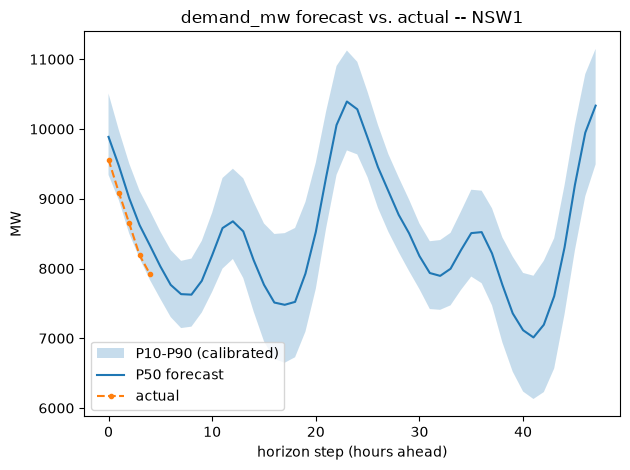

In [70]:
sample_region = ALL_MODEL_REGIONS[0]
region_df = engineered[engineered["region"] == sample_region].sort_values("ts").reset_index(drop=True)
origin_idx = len(region_df) - config.horizon - 1  # last real origin with a real future to score against

history = region_df.iloc[: origin_idx + 1]
actual = region_df[TARGET_COLUMN].iloc[origin_idx + 1 : origin_idx + 1 + config.horizon].to_numpy()

p10, p50, p90 = lstm_forecaster.predict(history, config.horizon)

fig, ax = plt.subplots()
steps = np.arange(config.horizon)
ax.fill_between(steps, p10, p90, alpha=0.25, label="P10-P90 (calibrated)")
ax.plot(steps, p50, label="P50 forecast")
ax.plot(steps, actual, label="actual", linestyle="--", marker="o", markersize=3)
ax.set_title(f"{TARGET_COLUMN} forecast vs. actual -- {sample_region}")
ax.set_xlabel("horizon step (hours ahead)")
ax.set_ylabel("MW")
ax.legend()
fig.tight_layout()


In [ ]:
# Real, verbatim ports of app/service/ml/prune.py's remaining helpers
# (compact_lstm itself is already in the next cell; state_dict_bytes,
# used below for the before/after artifact size, is Step 5-6's shared
# helper) -- self-contained, no app.* imports.
import time
from dataclasses import dataclass


def _unit_importance(weight_hh_l0, hidden_size):
    gates = weight_hh_l0.reshape(4, hidden_size, hidden_size)
    row_norm = torch.norm(gates, p=2, dim=(0, 2))
    col_norm = torch.norm(gates, p=2, dim=(0, 1))
    return row_norm + col_norm


def _select_units_to_keep(state_dict, hidden_size, keep_fraction):
    if not (0.0 < keep_fraction <= 1.0):
        raise ValueError("keep_fraction must be in (0, 1]")
    n_keep = max(1, round(hidden_size * keep_fraction))
    importance = _unit_importance(state_dict["lstm.weight_hh_l0"], hidden_size)
    keep_idx = torch.argsort(importance, descending=True)[:n_keep]
    return torch.sort(keep_idx).values


@dataclass
class PruneBenchmark:
    original_param_count: int
    pruned_param_count: int
    original_artifact_bytes: int
    pruned_artifact_bytes: int
    original_latency_ms: float
    pruned_latency_ms: float

    @property
    def param_reduction_pct(self) -> float:
        return 100.0 * (1 - self.pruned_param_count / self.original_param_count)

    @property
    def size_reduction_pct(self) -> float:
        return 100.0 * (1 - self.pruned_artifact_bytes / self.original_artifact_bytes)

    @property
    def latency_change_pct(self) -> float:
        return 100.0 * (self.pruned_latency_ms / self.original_latency_ms - 1)

    def achieves_a_real_win(self, *, min_size_reduction_pct: float = 5.0, max_latency_regression_pct: float = 10.0) -> bool:
        return (
            self.size_reduction_pct >= min_size_reduction_pct
            and self.latency_change_pct <= max_latency_regression_pct
        )


def _param_count(model) -> int:
    return sum(p.numel() for p in model.parameters())


def _measure_latency_ms(model, lookback, n_features, *, n_repeats: int = 20) -> float:
    model.eval()
    x = torch.randn(1, lookback, n_features)
    with torch.no_grad():
        model(x)  # warm-up
        start = time.perf_counter()
        for _ in range(n_repeats):
            model(x)
        elapsed = time.perf_counter() - start
    return (elapsed / n_repeats) * 1000


def benchmark_models(original, pruned, lookback) -> PruneBenchmark:
    return PruneBenchmark(
        original_param_count=_param_count(original),
        pruned_param_count=_param_count(pruned),
        original_artifact_bytes=state_dict_bytes(original),
        pruned_artifact_bytes=state_dict_bytes(pruned),
        original_latency_ms=_measure_latency_ms(original, lookback, original.n_features),
        pruned_latency_ms=_measure_latency_ms(pruned, lookback, pruned.n_features),
    )


In [72]:
def compact_lstm(
    model: DemandLSTM, keep_fraction: float
) -> tuple[DemandLSTM, torch.Tensor]:
    """Real structural compaction: builds a genuinely smaller
    `DemandLSTM` (`hidden_size = round(model.lstm.hidden_size *
    keep_fraction)`) and copies over exactly the surviving units' rows/
    columns for every affected tensor (`lstm.*`, `attention.score`, all
    3 output heads) -- not a zero-mask, a real shape change. Returns
    `(compacted_model, keep_idx)` -- `keep_idx` (the original model's
    unit indices that survived, ascending) is returned so a caller can
    verify/audit which units were kept, not just trust the count.

    `keep_fraction=1.0` is a real, exact no-op (verified in
    `tests/test_prune.py`): every unit "survives", and the returned
    model's weights equal the original's exactly.
    """
    hidden_size = model.lstm.hidden_size
    num_layers = model.lstm.num_layers
    state_dict = model.state_dict()
    keep_idx = _select_units_to_keep(state_dict, hidden_size, keep_fraction)
    n_keep = len(keep_idx)

    def _gate_rows(idx: torch.Tensor) -> torch.Tensor:
        """The 4 non-contiguous rows (one per gate) for each unit in
        `idx`, in `nn.LSTM`'s real row order (all of gate 0's rows, then
        all of gate 1's, ...) -- matches `weight_hh_l*`/`weight_ih_l*`'s
        actual on-disk row layout."""
        return torch.cat([idx + g * hidden_size for g in range(4)])

    gate_rows = _gate_rows(keep_idx)

    compacted = DemandLSTM(
        n_features=model.n_features,
        horizon=model.horizon,
        hidden_size=n_keep,
        num_layers=num_layers,
        dropout=model.lstm.dropout,
    )
    new_state = compacted.state_dict()

    for layer in range(num_layers):
        ih_key, hh_key = f"lstm.weight_ih_l{layer}", f"lstm.weight_hh_l{layer}"
        bih_key, bhh_key = f"lstm.bias_ih_l{layer}", f"lstm.bias_hh_l{layer}"

        weight_ih = state_dict[ih_key][gate_rows]
        if layer > 0:
            # Layers beyond the first take the *previous* (also pruned)
            # layer's hidden state as input, so the input dim is pruned
            # too -- layer 0's input is `n_features`, untouched.
            weight_ih = weight_ih[:, keep_idx]
        new_state[ih_key] = weight_ih
        new_state[hh_key] = state_dict[hh_key][gate_rows][:, keep_idx]
        new_state[bih_key] = state_dict[bih_key][gate_rows]
        new_state[bhh_key] = state_dict[bhh_key][gate_rows]

    new_state["attention.score.weight"] = state_dict["attention.score.weight"][
        :, keep_idx
    ]
    new_state["attention.score.bias"] = state_dict["attention.score.bias"]
    for head in ("point_head", "lower_spread_head", "upper_spread_head"):
        new_state[f"{head}.weight"] = state_dict[f"{head}.weight"][:, keep_idx]
        new_state[f"{head}.bias"] = state_dict[f"{head}.bias"]

    compacted.load_state_dict(new_state)
    # Real bug, confirmed live 2026-08-11 while adding `DemandLSTM.
    # head_dropout`: this function never propagated `model`'s train/eval
    # mode to the freshly-constructed `compacted` (which defaults to
    # `training=True`, `nn.Module`'s own default). Invisible until now
    # because the LSTM's only *previous* dropout site (its own inter-
    # layer `dropout=`) is a hard no-op whenever `num_layers=1` --
    # exactly the case `tests/test_prune.py`'s `keep_fraction=1.0` no-op
    # test happened to use. The moment a second, always-active dropout
    # site exists (`head_dropout`), a `compacted` left in training mode
    # would fire it stochastically even when `original_model` was
    # already `.eval()`'d (`prune_and_recover`'s caller always loads via
    # `load_registered_model`, which calls `.eval()`) -- silently
    # breaking the exact-output-match guarantee this function's own
    # docstring promises. Matching modes here is what keeps that
    # guarantee real regardless of how many dropout sites `DemandLSTM`
    # ever grows.
    compacted.train(model.training)
    return compacted, keep_idx

pruned_model, keep_idx = compact_lstm(result.model, keep_fraction=0.5)
benchmark = benchmark_models(result.model, pruned_model, config.lookback)

print(f"hidden_size: {result.model.lstm.hidden_size} -> {pruned_model.lstm.hidden_size}")
print(f"parameters:  {benchmark.original_param_count:,} -> {benchmark.pruned_param_count:,}  "
      f"({benchmark.param_reduction_pct:.1f}% fewer)")
print(f"artifact size: {benchmark.original_artifact_bytes:,} -> {benchmark.pruned_artifact_bytes:,} bytes  "
      f"({benchmark.size_reduction_pct:.1f}% smaller)")
print(f"CPU latency: {benchmark.original_latency_ms:.3f}ms -> {benchmark.pruned_latency_ms:.3f}ms  "
      f"({benchmark.latency_change_pct:+.1f}%, negative = faster)")
print(f"achieves a real win (>=5% smaller, <=10% slower)? {benchmark.achieves_a_real_win()}")


hidden_size: 128 -> 64
parameters:  236,305 -> 69,073  (70.8% fewer)
artifact size: 950,087 -> 281,159 bytes  (70.4% smaller)
CPU latency: 3.065ms -> 1.293ms  (-57.8%, negative = faster)
achieves a real win (>=5% smaller, <=10% slower)? True


In [73]:
# Real, verbatim ports of app/service/ml/emission_factors.py
# (GENERATION_BUCKET_FUEL_TYPES), app/service/ml/model_import.py
# (FEATURE_FINGERPRINT/MODEL_NAMES), and app/service/mlops/tracking.py
# (git_sha) -- self-contained, no `from app...` imports.
import subprocess

GENERATION_BUCKET_FUEL_TYPES: dict[str, tuple[str, ...]] = {
    "coal": ("coal",),
    "gas": ("gas",),
    "wind": ("wind",),
    "solar": ("solar_utility", "solar_rooftop"),
    "other": ("hydro", "biomass", "distillate", "pumped_hydro", "battery_discharge"),
}

# app/service/ml/model_import.py's real MODEL_NAMES -- "lstm_demand" is
# also Settings.mlflow_registry_model_name's real default
# (app/core/config.py), the actual registry name this whole notebook's
# LSTM training targets.
MODEL_NAME = "lstm_demand"
FEATURE_FINGERPRINT = ",".join(FEATURE_COLUMNS)


def git_sha() -> str | None:
    try:
        result = subprocess.run(
            ["git", "rev-parse", "HEAD"], capture_output=True, text=True, check=True, timeout=5,
        )
        return result.stdout.strip()
    except Exception:
        return None


def compute_bucket_factors(
    intensity_by_fuel_type: dict[str, float],
    generation_mw_by_fuel_type: dict[str, float],
) -> dict[str, float]:
    """Pure function, no DB dependency -- generation-weighted average
    factor per bucket: `sum(weight_i * factor_i) / sum(weight_i)` over
    each bucket's member fuel_types.

    Falls back to a plain (unweighted) mean of the member factors for a
    bucket if every member has zero/missing real generation weight (no
    real data yet to weight by) -- an honest degraded fallback, not
    silently producing 0 or raising, matching this platform's established
    convention of falling back to a documented approximation rather than
    failing when real weighting data is temporarily unavailable
    (`stg_openelectricity_mix.sql`'s own `renewable_mw_source` fallback
    is the same pattern one layer down).
    """
    result: dict[str, float] = {}
    for bucket, fuel_types in GENERATION_BUCKET_FUEL_TYPES.items():
        members = [ft for ft in fuel_types if ft in intensity_by_fuel_type]
        if not members:
            continue

        weighted_sum = 0.0
        total_weight = 0.0
        for ft in members:
            weight = max(generation_mw_by_fuel_type.get(ft, 0.0), 0.0)
            weighted_sum += weight * intensity_by_fuel_type[ft]
            total_weight += weight

        if total_weight > 0:
            result[bucket] = weighted_sum / total_weight
        else:
            result[bucket] = sum(intensity_by_fuel_type[ft] for ft in members) / len(members)

    return result


# The real NGER-2025-Q4 factors this pipeline trains against
# (services/waerehouse/dbt/ecolens/seeds/emissions_factors.csv), read directly rather
# than via a live Postgres seed table -- same real numbers, DuckDB-only path.
INTENSITY_BY_FUEL_TYPE_KGCO2E_PER_MWH = {
    "coal": 910.0,
    "gas": 490.0,
    "diesel": 770.0,
    "distillate": 770.0,
    "hydro": 5.0,
    "wind": 4.0,
    "solar_utility": 5.0,
    "solar_rooftop": 5.0,
    "biomass": 0.0,
    "battery": 0.0,
    "battery_discharge": 0.0,
    "battery_charge": 0.0,
    "pumped_hydro": 0.0,
    "net_import": 0.0,
}

carbon_region = ALL_MODEL_REGIONS[0]
fuel_cols = sorted({ft for members in GENERATION_BUCKET_FUEL_TYPES.values() for ft in members})
select_cols = ", ".join(f"avg(oe_{ft}_mw) AS {ft}" for ft in fuel_cols)

# master is an in-memory view registered on duckdb's default connection
# (duckdb.register("master", df), Step 2 above) -- NOT a table inside
# landed.duckdb itself. Opening a fresh duckdb.connect(db_path) here (a
# separate connection to the raw staging file) can't see it -- query via
# duckdb.sql(...)/the default connection instead, same pattern Step 2's
# own coverage check already uses.
mix_row = duckdb.sql(
    f"""
    SELECT region, {select_cols}, avg(aemo_demand_mw) AS demand_mw
    FROM master
    WHERE region = $carbon_region AND bucket_ts >= (SELECT max(bucket_ts) FROM master WHERE region = $carbon_region) - INTERVAL 7 DAY
    GROUP BY region
    """,
    params={"carbon_region": carbon_region},
).df().iloc[0]

generation_mw_by_fuel_type = {ft: max(float(mix_row[ft]), 0.0) for ft in fuel_cols}
bucket_factors = compute_bucket_factors(INTENSITY_BY_FUEL_TYPE_KGCO2E_PER_MWH, generation_mw_by_fuel_type)
print(f"real generation-weighted bucket factors for {carbon_region} (kgCO2e/MWh == gCO2e/kWh):")
bucket_factors


import io
import json
import tempfile
import zipfile

import onnx
import onnxruntime as ort
from torch import nn

ONNX_OPSET = 17


def _scaler_to_json(scaler) -> dict:
    """Same plain-JSON shape as Step 14's `.pt`-bundle counterpart
    (`forcast_pipeline.ipynb`) -- no pickle, four plain numbers per
    scaler, never unpickled on the receiving end."""
    return {
        "mean": scaler.mean_.tolist(),
        "scale": scaler.scale_.tolist(),
        "var": scaler.var_.tolist(),
        "n_samples_seen": int(scaler.n_samples_seen_),
    }


def _find_clean_window(df: pd.DataFrame, lookback: int, columns: list[str]) -> pd.DataFrame:
    """The most recent `lookback`-row window with no NaN in `columns` --
    scans backward rather than blindly trusting the last `lookback` rows.
    Real, current data: lag/rolling/weather columns have genuine gaps
    (confirmed directly -- the most recent window at the time this was
    written had 18 NaNs in `price_mwh` alone), the same real-world gaps
    `Forecaster.predict`'s own "return all-NaN rather than raise"
    contract exists to tolerate silently. That's the right behavior for
    a live-serving/backtest call; it's the *wrong* one for this cell's
    export self-check, whose entire job is proving the export is
    trustworthy -- silently verifying against NaN would prove nothing."""
    for end in range(len(df), lookback - 1, -1):
        window = df.iloc[end - lookback : end]
        if not window[columns].isna().any().any():
            return window
    raise ValueError(f"no NaN-free {lookback}-row window found in {len(df):,} rows")


class _OnnxExportWrapper(nn.Module):
    """Calls the real trained model and unpacks its `DemandForecast`
    dataclass into a plain tuple -- `torch.onnx.export` traces tensor
    I/O, not dataclasses. No computation happens here; this only
    reshapes the return value."""

    def __init__(self, model: nn.Module) -> None:
        super().__init__()
        self.model = model

    def forward(self, x):
        out = self.model(x)
        return out.p10, out.p50, out.p90


result.model.eval()
export_wrapper = _OnnxExportWrapper(result.model)
export_wrapper.eval()

# `region_df` (Step 9, still in scope -- Step 13's cleanup cell doesn't
# free it) is that region's *full* engineered history, not just the
# narrower `history` slice Step 9 plotted from -- more room to find a
# real NaN-free window in.
sample_window = _find_clean_window(region_df, config.lookback, list(FEATURE_COLUMNS))
sample_region = sample_window["region"].iloc[-1]
sample_scaler = result.feature_scalers[sample_region]
sample_scaled = apply_scalers(sample_window, {sample_region: sample_scaler})
sample_x = torch.tensor(
    sample_scaled[list(FEATURE_COLUMNS)].to_numpy(dtype=np.float32)
).unsqueeze(0)

with tempfile.TemporaryDirectory() as tmp_dir:
    onnx_path = Path(tmp_dir) / "model.onnx"
    torch.onnx.export(
        export_wrapper,
        (sample_x,),
        str(onnx_path),
        input_names=["x"],
        output_names=["p10", "p50", "p90"],
        dynamic_axes={
            "x": {0: "batch"},
            "p10": {0: "batch"},
            "p50": {0: "batch"},
            "p90": {0: "batch"},
        },
        opset_version=ONNX_OPSET,
        dynamo=False,  # legacy exporter -- see this step's markdown for why
    )
    onnx_bytes = onnx_path.read_bytes()

# Stage 1 of the design doc's validation pipeline: structural validity.
onnx.checker.check_model(onnx.load_from_string(onnx_bytes))

# Stage 2: the real sanity forward pass -- same real (NaN-free) input
# through both runtimes, real numeric agreement asserted, not assumed.
ort_session = ort.InferenceSession(onnx_bytes, providers=["CPUExecutionProvider"])
ort_p10, ort_p50, ort_p90 = ort_session.run(None, {"x": sample_x.numpy()})

with torch.no_grad():
    torch_out = result.model(sample_x)

max_diff = max(
    np.abs(ort_p10 - torch_out.p10.numpy()).max(),
    np.abs(ort_p50 - torch_out.p50.numpy()).max(),
    np.abs(ort_p90 - torch_out.p90.numpy()).max(),
)
assert max_diff < 1e-4, f"ONNX output diverged from PyTorch by {max_diff} -- export is not trustworthy"
print(f"ONNX vs PyTorch max abs diff: {max_diff:.2e}  (float32 precision, not zero, expected)")

manifest = {
    "manifest_version": 1,
    "bundle_format": "onnx",
    "model_name": f"{MODEL_NAME}_onnx",
    "architecture_note": f"DemandLSTM exported to ONNX opset {ONNX_OPSET} (PyTorch {torch.__version__})",
    "horizon": config.horizon,
    "lookback": config.lookback,
    "feature_columns": list(FEATURE_COLUMNS),
    "input_name": "x",
    "input_shape": [None, config.lookback, len(FEATURE_COLUMNS)],
    "output_type": "quantile3",
    "output_names": {"p10": "p10", "p50": "p50", "p90": "p90"},
    # Inverse-scaling/bias-correction/conformal-calibration are NOT baked
    # into the graph -- applied outside it against the shipped scalers/
    # calibration files below, same convention LSTM/TFT already use.
    "output_space": "scaled",
    "regions": list(ALL_MODEL_REGIONS),
    "feature_fingerprint": FEATURE_FINGERPRINT,
    "source_note": f"forcast_pipelineV2.ipynb tutorial run (ONNX export), git_sha={git_sha() or 'unknown'}",
}

feature_scalers_json = {region: _scaler_to_json(s) for region, s in result.feature_scalers.items()}
target_scaler_json = {region: _scaler_to_json(s) for region, s in result.target_scaler.items()}

onnx_bundle_path = Path.cwd() / f"{MODEL_NAME}_onnx_bundle.zip"
with zipfile.ZipFile(onnx_bundle_path, "w", zipfile.ZIP_DEFLATED) as zf:
    zf.writestr("manifest.json", json.dumps(manifest, indent=2))
    zf.writestr("model.onnx", onnx_bytes)
    zf.writestr("feature_scalers.json", json.dumps(feature_scalers_json))
    zf.writestr("target_scaler.json", json.dumps(target_scaler_json))
    zf.writestr("conformal_calibration.json", json.dumps(result.calibration.to_dict()))
    zf.writestr("demand_bias_correction.json", json.dumps(result.bias_correction.to_dict()))

print(f"wrote {onnx_bundle_path} ({onnx_bundle_path.stat().st_size:,} bytes)")
print(f"regions: {list(ALL_MODEL_REGIONS)}  format: onnx (opset {ONNX_OPSET})  horizon: {config.horizon}  lookback: {config.lookback}")
print()
print("POST /v1/model/versions/import-onnx is real and shipped")
print("(services/forecast-api/app/api/v1/model/routes.py) -- this bundle can be")
print("uploaded there directly, the same way the existing `.pt` bundle uploads to")
print("POST /v1/model/versions/import.")


real generation-weighted bucket factors for NSW1 (kgCO2e/MWh == gCO2e/kWh):


/var/folders/h4/m35y7z316y5cj4p1dvcz4x6h0000gn/T/ipykernel_95373/3779615500.py:192: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/Users/macbook/Project/research/EcoLens/services/forecast-api/.venv/lib/python3.13/site-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset9.py:4462: UserWarning: Exporting a model to ONNX with a batch_size other than 1, with a variable length with LSTM can cause an error when running the ONNX model with a different batch size. Make sure to save the model with a batch size of 1, or define the initial states (h0/c0) as inputs of the model. 
  return _generic_rnn(


ONNX vs PyTorch max abs diff: 3.58e-07  (float32 precision, not zero, expected)
wrote /Users/macbook/Project/research/EcoLens/services/forecast-api/notebooks/lstm_demand_onnx_bundle.zip (886,776 bytes)
regions: ['NSW1', 'QLD1', 'VIC1', 'SA1', 'TAS1', 'WEM']  format: onnx (opset 17)  horizon: 48  lookback: 24

POST /v1/model/versions/import-onnx is real and shipped
(services/forecast-api/app/api/v1/model/routes.py) -- this bundle can be
uploaded there directly, the same way the existing `.pt` bundle uploads to
POST /v1/model/versions/import.
